In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/images.txt
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/hw3.m~
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/timages.txt
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/m_images.txt
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/tm_images.txt
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/mask_orange/b3.jpg
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/mask_orange/b9.jpg
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/mask_orange/b1.jpg
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/mask_orange/b10.jpg
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/mask_orange/b7.jpg
/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification/mask_orange

In [1]:
import os
import glob
import pandas as pd
from PIL import Image

# 1. Path where dataset is unzipped / downloaded
DATA_DIR = "/kaggle/input/datasets/ayanzadeh93/color-classification/ColorClassification"

# Strict list of target color classes
VALID_COLORS = [
    'red', 'green', 'blue', 'yellow', 'orange', 
    'brown', 'violet', 'black', 'white', 'grey', 'gray'
]

# Non-color keywords to strictly exclude
EXCLUDE_KEYWORDS = ['mask', 'test', 'temp', 'unlabeled']

data = []

# Walk through directories
for root, dirs, files in os.walk(DATA_DIR):
    # Parse folder hierarchy in lower case
    path_parts = [p.lower() for p in os.path.normpath(root).split(os.sep)]
    folder_name = os.path.basename(root).lower()
    
    # ---------------------------------------------------------
    # Filter 1: Skip non-color/mask/test folders completely
    # ---------------------------------------------------------
    if any(keyword in part for part in path_parts for keyword in EXCLUDE_KEYWORDS):
        continue
        
    # Check if current directory matches an explicit valid color
    matched_color = next((color for color in VALID_COLORS if color in path_parts), None)
    if matched_color is None:
        continue  # Omit any non-color directories
        
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            # Omit mask files based on filename patterns
            if 'mask' in file.lower():
                continue
                
            full_path = os.path.join(root, file)
            
            # Extract image dimensions
            try:
                with Image.open(full_path) as img:
                    width, height = img.size
                    mode = img.mode  # RGB, L, etc.
                    
                data.append({
                    'filepath': full_path,
                    'label': matched_color.capitalize(),  # Standardized clean class label
                    'width': width,
                    'height': height,
                    'mode': mode
                })
            except Exception as e:
                # Skip any corrupted images
                continue

df = pd.DataFrame(data)

# Print DataFrame preview and clean class distribution
print(df.head())
print("\nClass Distribution (Distinct Color Classes Only):")
print(df['label'].value_counts())

                                            filepath   label  width  height  \
0  /kaggle/input/datasets/ayanzadeh93/color-class...  Orange    300     199   
1  /kaggle/input/datasets/ayanzadeh93/color-class...  Orange   1000     995   
2  /kaggle/input/datasets/ayanzadeh93/color-class...  Orange    225     225   
3  /kaggle/input/datasets/ayanzadeh93/color-class...  Orange    350     350   
4  /kaggle/input/datasets/ayanzadeh93/color-class...  Orange    570     570   

  mode  
0  RGB  
1  RGB  
2  RGB  
3  RGB  
4  RGB  

Class Distribution (Distinct Color Classes Only):
label
Brown     40
Black     22
Violet    20
Blue      20
White     17
Green     14
Red       12
Orange    10
Yellow    10
Name: count, dtype: int64


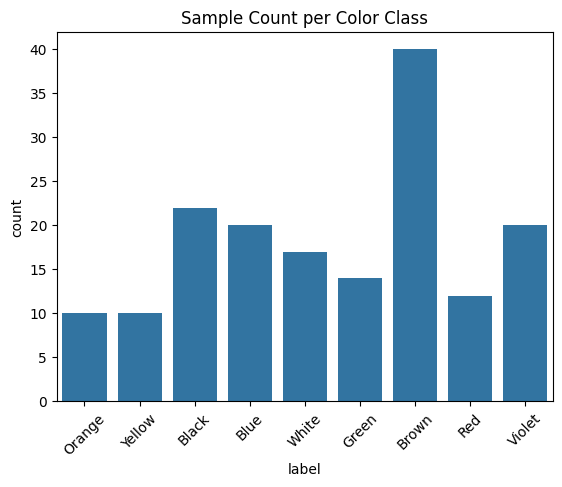

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='label')
plt.xticks(rotation=45)
plt.title("Sample Count per Color Class")
plt.show()

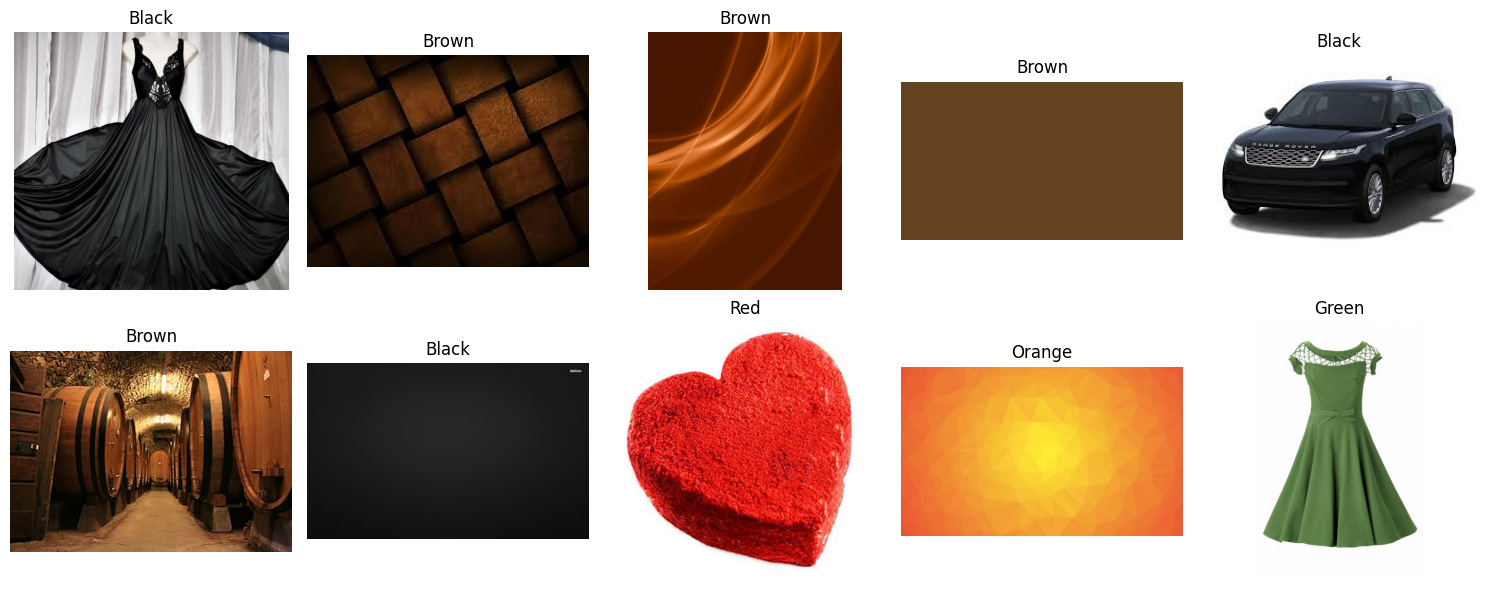

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
sample_df = df.sample(10)

for ax, (_, row) in zip(axes.flatten(), sample_df.iterrows()):
    img = Image.open(row['filepath'])
    ax.imshow(img)
    ax.set_title(row['label'])
    ax.axis('off')
plt.tight_layout()
plt.show()

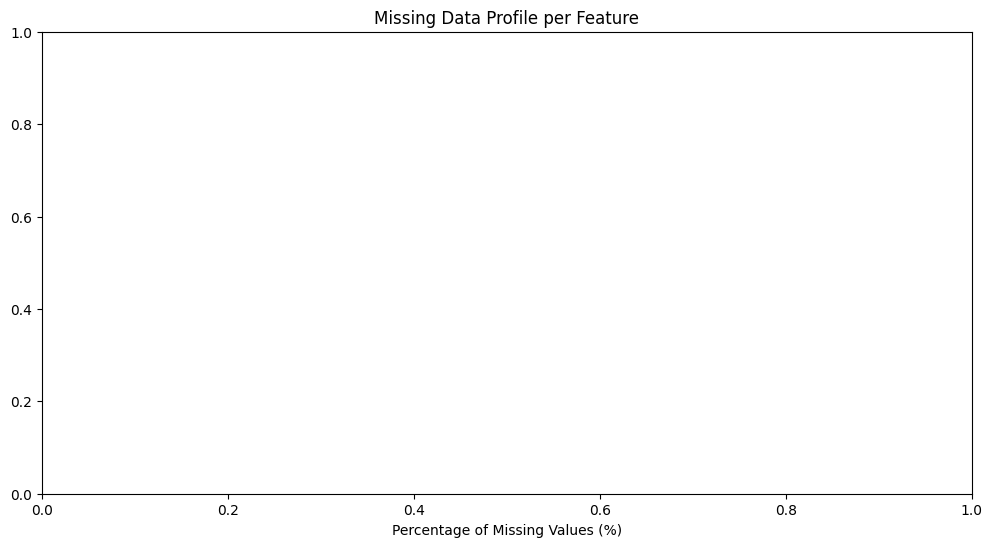

In [4]:
# Calculate percentage of missing values per column
missing_pct = df.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

# Plot the missing data distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_pct.values, y=missing_pct.index, palette="viridis")
plt.xlabel("Percentage of Missing Values (%)")
plt.title("Missing Data Profile per Feature")
plt.show()

In [5]:
import numpy as np
import pandas as pd
import cv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFECV

# 1. Feature Extraction Function
def extract_color_features(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None
        
    # Convert image to target color spaces
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    feats = {}
    
    # RGB Channel Statistics
    feats['rgb_r_mean'] = np.mean(img_rgb[:, :, 0])
    feats['rgb_g_mean'] = np.mean(img_rgb[:, :, 1])
    feats['rgb_b_mean'] = np.mean(img_rgb[:, :, 2])
    feats['rgb_r_std']  = np.std(img_rgb[:, :, 0])
    feats['rgb_g_std']  = np.std(img_rgb[:, :, 1])
    feats['rgb_b_std']  = np.std(img_rgb[:, :, 2])

    # HSV Channel Statistics
    feats['hsv_h_mean'] = np.mean(img_hsv[:, :, 0])
    feats['hsv_s_mean'] = np.mean(img_hsv[:, :, 1])
    feats['hsv_v_mean'] = np.mean(img_hsv[:, :, 2])
    
    # CIELAB Channel Statistics (Perceptually Uniform)
    feats['lab_l_mean'] = np.mean(img_lab[:, :, 0])
    feats['lab_a_mean'] = np.mean(img_lab[:, :, 1])  # Green-Red spectrum
    feats['lab_b_mean'] = np.mean(img_lab[:, :, 2])  # Blue-Yellow spectrum
    
    # 8-Bin Hue Histogram (Captures dominant hue distribution)
    hue_hist, _ = np.histogram(img_hsv[:, :, 0], bins=8, range=(0, 180), density=True)
    for i, val in enumerate(hue_hist):
        feats[f'hue_bin_{i}'] = val
        
    return feats

# 2. Extract Features from your existing DataFrame
print("Extracting features from dataset...")
extracted = df['filepath'].apply(extract_color_features)
X = pd.DataFrame(list(extracted))
y = df['label']

# 3. Clean any unreadable images if present
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# If your df has a column distinguishing train/test splits (e.g. df['split'] == 'train'):
# train_mask = df.loc[valid_idx, 'split'] == 'train'
# X_train, y_train = X[train_mask], y[train_mask]
# X_test, y_test = X[~train_mask], y[~train_mask]

# Otherwise, perform a stratified split on your dataset:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# 4. Train Random Forest Model
rf = RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Output test classification metrics
y_pred = rf.predict(X_test)
print("\n--- Test Set Metrics ---")
print(classification_report(y_test, y_pred))

# 5. Determine Optimal Predictor Color Features via Permutation Importance
# Evaluates drop in F1-score when shuffling each feature
perm = permutation_importance(
    rf, X_test, y_test, 
    scoring='f1_macro', 
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'F1_Drop_Mean': perm.importances_mean,
    'F1_Drop_Std': perm.importances_std
}).sort_values(by='F1_Drop_Mean', ascending=False)

print("\n--- Top Predictor Color Features (by F1-Score Impact) ---")
print(importance_df.head(10))

# 6. Feature Selection via Recursive Feature Elimination (RFECV)
rfecv = RFECV(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42),
    step=1,
    cv=5,
    scoring='precision_macro',  # Can change to 'recall_macro' or 'f1_macro'
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

selected_features = list(X.columns[rfecv.support_])
print(f"\nOptimal Number of Color Features: {rfecv.n_features_}")
print("Selected Feature Subset:", selected_features)

Extracting features from dataset...

--- Test Set Metrics ---
              precision    recall  f1-score   support

       Black       0.86      1.00      0.92         6
        Blue       1.00      0.60      0.75         5
       Brown       0.77      1.00      0.87        10
       Green       1.00      1.00      1.00         4
      Orange       0.00      0.00      0.00         2
         Red       1.00      0.67      0.80         3
      Violet       1.00      0.80      0.89         5
       White       0.67      1.00      0.80         4
      Yellow       1.00      1.00      1.00         3

    accuracy                           0.86        42
   macro avg       0.81      0.79      0.78        42
weighted avg       0.85      0.86      0.83        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



--- Top Predictor Color Features (by F1-Score Impact) ---
       Feature  F1_Drop_Mean  F1_Drop_Std
11  lab_b_mean      0.053960     0.053852
10  lab_a_mean      0.047479     0.042493
18   hue_bin_6      0.035808     0.035958
16   hue_bin_4      0.027601     0.027641
13   hue_bin_1      0.027273     0.009091
6   hsv_h_mean      0.013621     0.008917
0   rgb_r_mean      0.012375     0.037508
19   hue_bin_7      0.007103     0.012003
15   hue_bin_3      0.006049     0.012099
14   hue_bin_2      0.003025     0.009074


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m


Optimal Number of Color Features: 4
Selected Feature Subset: ['rgb_g_mean', 'hsv_v_mean', 'lab_a_mean', 'lab_b_mean']


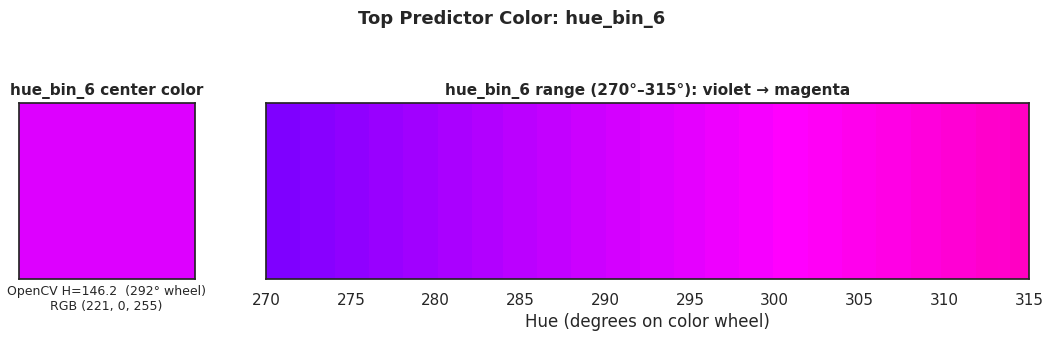

hue_bin_6 -> OpenCV H [135.0, 157.5)  =  [270°, 315°) on the wheel
Representative RGB (center hue): (221, 0, 255)  (violet/magenta)


In [13]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# hue_bin_6 from an 8-bin histogram over OpenCV hue (0-180)
BIN, N_BINS = 6, 8
low  = BIN * 180 / N_BINS          # 135.0
high = (BIN + 1) * 180 / N_BINS    # 157.5
center = (low + high) / 2          # 146.25   (=> 292.5° on the 0-360 wheel)

# Solid swatch at the bin's center hue (full saturation & value)
center_hsv = np.uint8([[[int(round(center)), 255, 255]]])
center_rgb = cv2.cvtColor(center_hsv, cv2.COLOR_HSV2RGB)[0, 0]

# Gradient strip across the bin's hue range
strip_h = np.linspace(low, high, 200).astype(np.uint8)
strip_hsv = np.stack([strip_h,
                      np.full_like(strip_h, 255),
                      np.full_like(strip_h, 255)], axis=1).reshape(1, -1, 3)
strip_rgb = cv2.cvtColor(strip_hsv, cv2.COLOR_HSV2RGB)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2),
                         gridspec_kw={'width_ratios': [1, 3]})

axes[0].imshow(np.array([[center_rgb / 255.0]]))
axes[0].set_title('hue_bin_6 center color', fontweight='bold', fontsize=11)
axes[0].set_xlabel(f"OpenCV H={center:.1f}  ({center*2:.0f}° wheel)\nRGB {tuple(int(v) for v in center_rgb)}",
                   fontsize=9)
axes[0].set_xticks([]); axes[0].set_yticks([])

axes[1].imshow(strip_rgb, extent=[low*2, high*2, 0, 1], aspect='auto')  # x-axis in wheel degrees
axes[1].set_title('hue_bin_6 range (270°–315°): violet → magenta', fontweight='bold', fontsize=11)
axes[1].set_xlabel('Hue (degrees on color wheel)')
axes[1].set_yticks([])

plt.suptitle('Top Predictor Color: hue_bin_6', fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

print(f"hue_bin_6 -> OpenCV H [{low:.1f}, {high:.1f})  =  [{low*2:.0f}°, {high*2:.0f}°) on the wheel")
print(f"Representative RGB (center hue): {tuple(int(v) for v in center_rgb)}  (violet/magenta)")

collinearity assumption

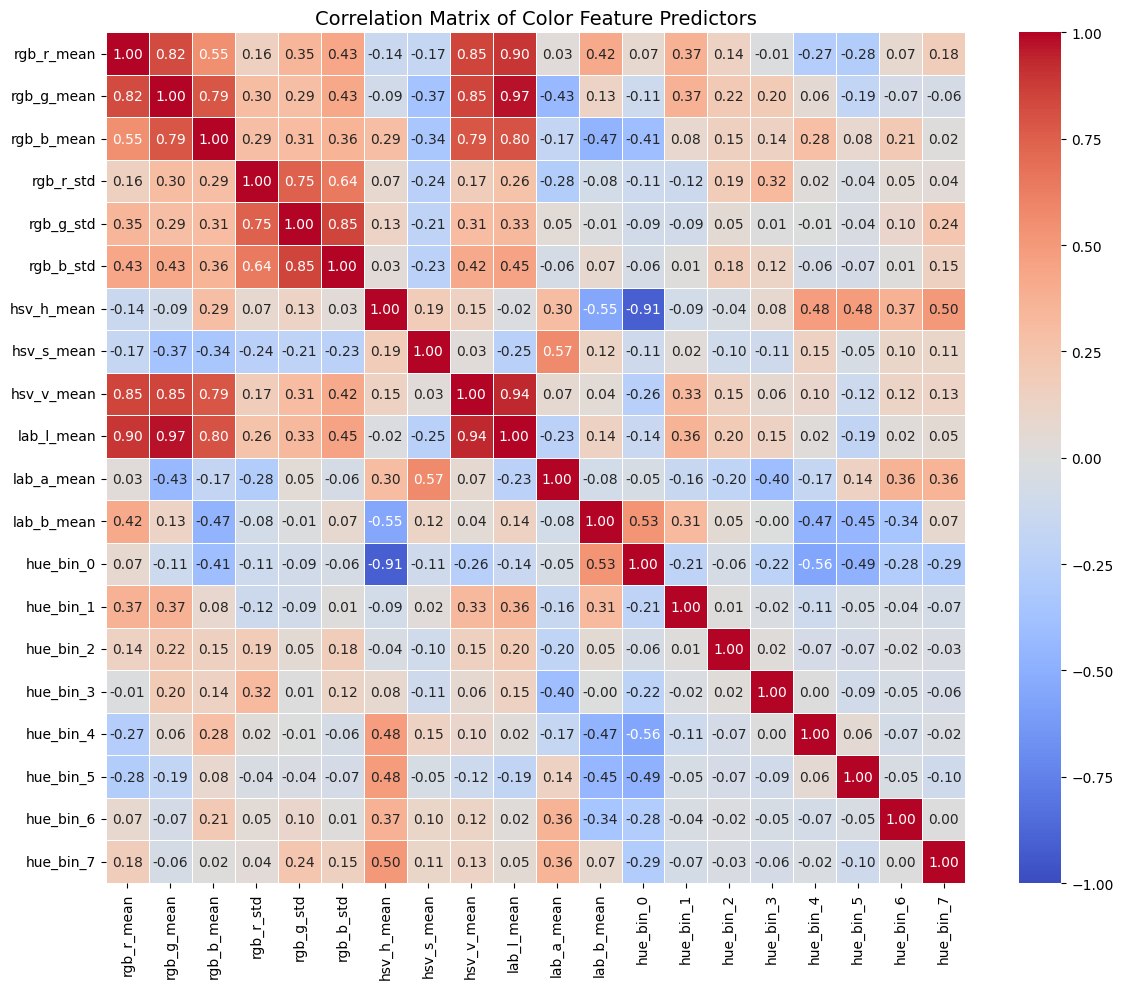

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute Pearson correlation matrix across feature matrix X
corr_matrix = X.corr()

# Plot heat map
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5
)
plt.title("Correlation Matrix of Color Feature Predictors", fontsize=14)
plt.tight_layout()
plt.show()

Extracting features...
Clean samples: 165 | classes: ['Black', 'Blue', 'Brown', 'Green', 'Orange', 'Red', 'Violet', 'White', 'Yellow']


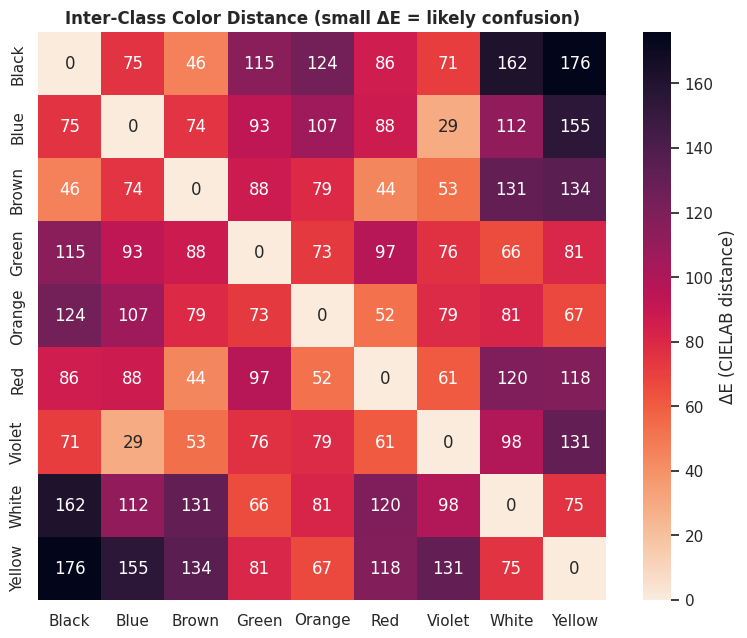

Most confusable class pairs (smallest ΔE):
  Blue     <-> Violet     ΔE = 29.1
  Brown    <-> Red        ΔE = 44.3
  Black    <-> Brown      ΔE = 46.4
  Orange   <-> Red        ΔE = 52.4
  Brown    <-> Violet     ΔE = 53.2


In [10]:
import seaborn as sns
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

VALID_COLORS = ['black','blue','brown','green','orange','red','violet','white','yellow']

# 16 standard color anchors (canonical RGB -> CIELAB), no custom palette
ANCHOR_COLORS = ['red','green','blue','yellow','orange','brown','violet','black',
                 'white','grey','pink','purple','cyan','magenta','gold','tan']
A_rgb = np.array([[int(c*255) for c in mcolors.to_rgb(n)] for n in ANCHOR_COLORS], np.uint8)
A_lab = cv2.cvtColor(A_rgb.reshape(-1,1,3), cv2.COLOR_RGB2LAB).reshape(-1,3).astype(np.float32)

# ---------------------------------------------------------
# Single rich feature extractor (union of all model inputs)
# ---------------------------------------------------------
def extract_all_features(path):
    img = cv2.imread(path)
    if img is None:
        return None
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = (gray > 20) & (gray < 235)
    if mask.sum() == 0:
        mask = np.ones_like(gray, dtype=bool)

    f = {}
    for i, ch in enumerate(['r','g','b']):
        f[f'rgb_{ch}_mean'] = rgb[:,:,i][mask].mean()
        f[f'rgb_{ch}_std']  = rgb[:,:,i][mask].std()
    f['hsv_h_mean'] = hsv[:,:,0][mask].mean()
    f['hsv_s_mean'] = hsv[:,:,1][mask].mean()
    f['hsv_v_mean'] = hsv[:,:,2][mask].mean()
    f['lab_l_mean'] = lab[:,:,0][mask].mean()
    f['lab_a_mean'] = lab[:,:,1][mask].mean()
    f['lab_b_mean'] = lab[:,:,2][mask].mean()
    hue_hist, _ = np.histogram(hsv[:,:,0][mask], bins=8, range=(0,180), density=True)
    for i, v in enumerate(hue_hist):
        f[f'hue_bin_{i}'] = v
    rgb_sum = rgb.sum(axis=2) + 1e-6
    f['norm_r'] = (rgb[:,:,0]/rgb_sum)[mask].mean()
    f['norm_g'] = (rgb[:,:,1]/rgb_sum)[mask].mean()
    f['norm_b'] = (rgb[:,:,2]/rgb_sum)[mask].mean()
    # 16 anchor indicators (nearest anchor in CIELAB = 1)
    mean_lab = np.array([lab[:,:,c][mask].mean() for c in range(3)])
    dist = np.linalg.norm(A_lab - mean_lab, axis=1)
    onehot = (dist == dist.min()).astype(float)
    for i, n in enumerate(ANCHOR_COLORS):
        f[f'ind_{n}'] = onehot[i]
    return f

# ---------------------------------------------------------
# Build clean 9-class feature frame  (reused by later cells)
# ---------------------------------------------------------
def clean_label(path, raw):
    for c in VALID_COLORS:
        if c in str(path).lower():
            return c.capitalize()
    return str(raw).capitalize() if str(raw).lower() in VALID_COLORS else None

print("Extracting features...")
feats = df['filepath'].apply(extract_all_features)
feat_df = pd.DataFrame(list(feats))
feat_df['label'] = [clean_label(p, l) for p, l in zip(df['filepath'], df['label'])]
feat_df = feat_df.dropna().reset_index(drop=True)
print(f"Clean samples: {len(feat_df)} | classes: {sorted(feat_df['label'].unique())}")

y = feat_df['label']
ind_cols  = [c for c in feat_df.columns if c.startswith('ind_')]
rich_cols = [c for c in feat_df.columns if c not in ['label'] + ind_cols]


# Per-class mean CIELAB, then pairwise Euclidean distance (ΔE)
class_lab = feat_df.groupby('label')[['lab_l_mean','lab_a_mean','lab_b_mean']].mean()
classes = class_lab.index.tolist()
M = class_lab.values
deltaE = np.linalg.norm(M[:,None,:] - M[None,:,:], axis=2)

plt.figure(figsize=(8,6.5))
sns.heatmap(pd.DataFrame(deltaE, index=classes, columns=classes),
            annot=True, fmt='.0f', cmap='rocket_r', square=True,
            cbar_kws={'label':'ΔE (CIELAB distance)'})
plt.title('Inter-Class Color Distance (small ΔE = likely confusion)', fontweight='bold')
plt.tight_layout()
plt.show()

# Report the closest (most confusable) class pairs
pairs = [(classes[i], classes[j], deltaE[i,j])
         for i in range(len(classes)) for j in range(i+1, len(classes))]
closest = sorted(pairs, key=lambda x: x[2])[:5]
print("Most confusable class pairs (smallest ΔE):")
for a, b, d in closest:
    print(f"  {a:8s} <-> {b:8s}   ΔE = {d:.1f}")

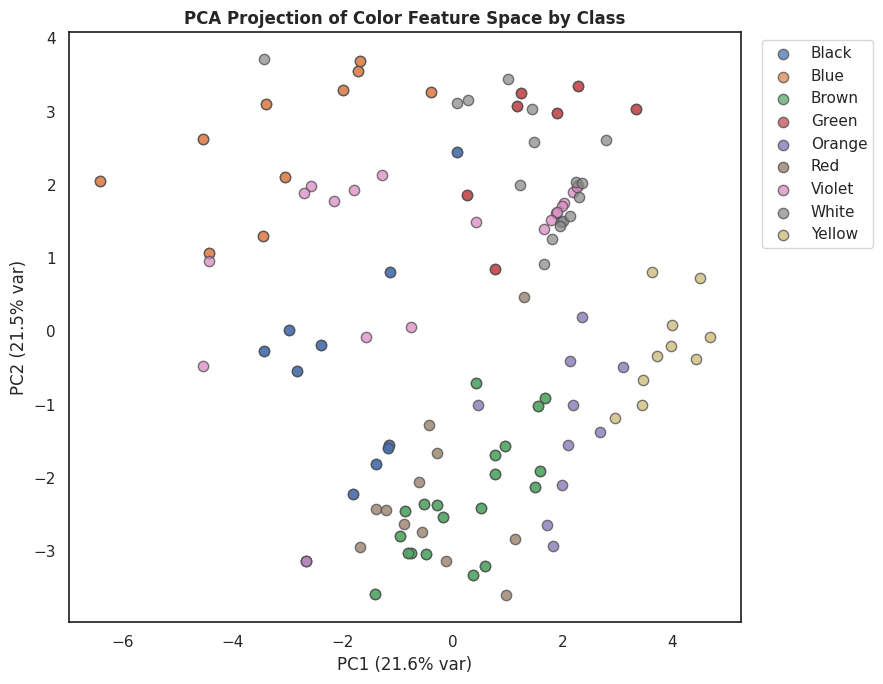

Total variance captured by 2 PCs: 43.1%


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

Xr = StandardScaler().fit_transform(feat_df[rich_cols])
pca = PCA(n_components=2, random_state=42)
proj = pca.fit_transform(Xr)

plt.figure(figsize=(9,7))
for label in sorted(feat_df['label'].unique()):
    m = (feat_df['label'] == label).values
    plt.scatter(proj[m,0], proj[m,1], label=label, s=55, alpha=0.75, edgecolor='0.3')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA Projection of Color Feature Space by Class', fontweight='bold')
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()
print(f"Total variance captured by 2 PCs: {pca.explained_variance_ratio_[:2].sum()*100:.1f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


 MODEL 1: Single Predictor (lab_b_mean alone)
 Target: ALL COLOR CLASSES
              precision    recall  f1-score   support

       Black       0.43      1.00      0.60         6
        Blue       0.67      0.40      0.50         5
       Brown       0.48      1.00      0.65        10
       Green       0.00      0.00      0.00         4
      Orange       0.00      0.00      0.00         2
         Red       0.00      0.00      0.00         3
      Violet       0.00      0.00      0.00         5
       White       0.00      0.00      0.00         4
      Yellow       1.00      0.33      0.50         3

    accuracy                           0.45        42
   macro avg       0.29      0.30      0.25        42
weighted avg       0.33      0.45      0.33        42


 VIF BEFORE ADJUSTMENT (all 3 top predictors)
      Feature       VIF
0   hue_bin_6  1.376700
1  lab_a_mean  1.208899
2  lab_b_mean  1.157589

 VIF AFTER ADJUSTMENT (retained 3 predictors)
      Feature       VIF
0   hue_

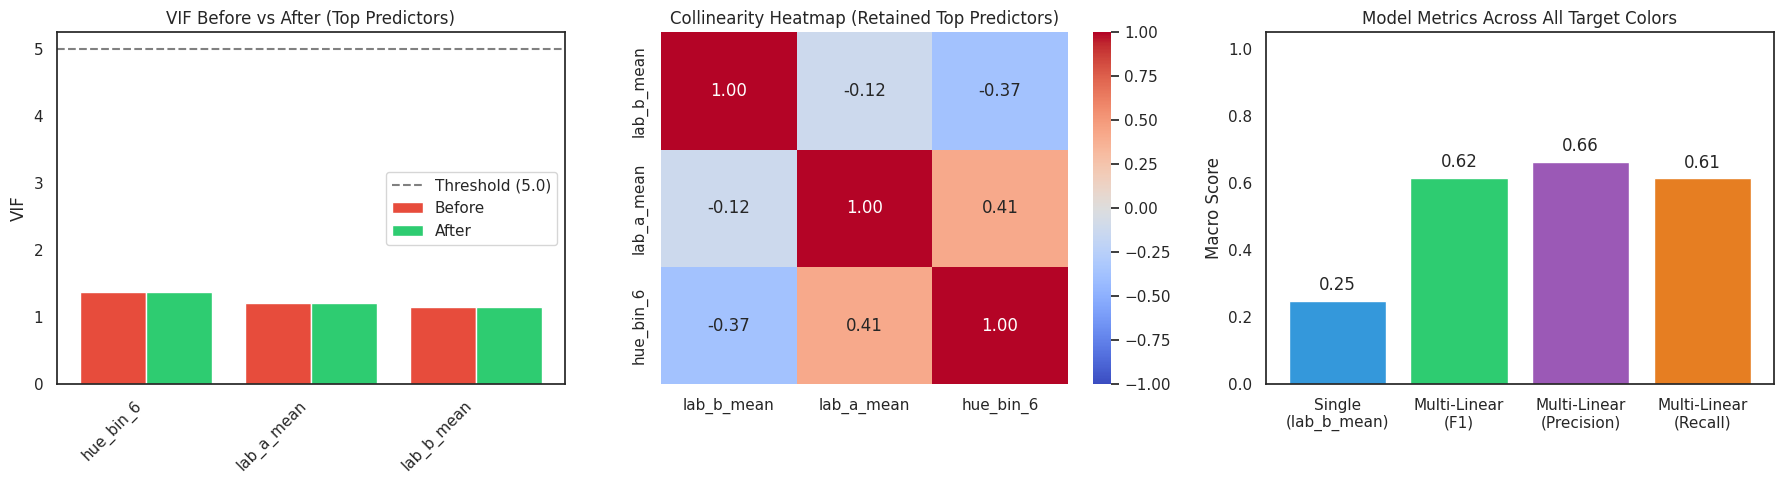

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---------------------------------------------------------
# 1. Feature Extraction: Top RF Predictors (lab_b, lab_a, hue_bin_6)
# ---------------------------------------------------------
def extract_top_features(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)

    hue_hist, _ = np.histogram(img_hsv[:, :, 0], bins=8, range=(0, 180), density=True)
    return {
        'lab_b_mean': np.mean(img_lab[:, :, 2]),   # Blue-Yellow spectrum (top predictor)
        'lab_a_mean': np.mean(img_lab[:, :, 1]),   # Green-Red spectrum
        'hue_bin_6':  hue_hist[6],                 # dominant-hue bin [135,157.5)
    }

features_data = df['filepath'].apply(extract_top_features)
X_full = pd.DataFrame(list(features_data))
y_full = df['label']

valid_idx = X_full.dropna().index
X_full = X_full.loc[valid_idx]
y_full = y_full.loc[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.25, random_state=42, stratify=y_full
)

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# ---------------------------------------------------------
# 2. Model 1: Single Predictor (lab_b_mean alone -> All Colors)
# ---------------------------------------------------------
model_single = LogisticRegression(multi_class='multinomial', max_iter=1000)
model_single.fit(X_train_scaled[['lab_b_mean']], y_train)
y_pred_single = model_single.predict(X_test_scaled[['lab_b_mean']])
print("==================================================")
print(" MODEL 1: Single Predictor (lab_b_mean alone)")
print(" Target: ALL COLOR CLASSES")
print("==================================================")
print(classification_report(y_test, y_pred_single, zero_division=0))

# ---------------------------------------------------------
# 3. VIF Helper + Iterative Collinearity Adjustment
# ---------------------------------------------------------
def compute_vif(frame):
    return pd.DataFrame({
        'Feature': frame.columns,
        'VIF': [variance_inflation_factor(frame.values, i) for i in range(frame.shape[1])]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

VIF_THRESHOLD = 5.0

# --- BEFORE: VIF on all top predictors ---
vif_before = compute_vif(X_train_scaled)
print("\n==================================================")
print(f" VIF BEFORE ADJUSTMENT (all {X_train_scaled.shape[1]} top predictors)")
print("==================================================")
print(vif_before)

# --- ADJUST: drop the highest-VIF feature until all VIF <= threshold ---
retained = list(X_train_scaled.columns)
while True:
    vif_iter = compute_vif(X_train_scaled[retained])
    worst = vif_iter.iloc[0]
    if worst['VIF'] > VIF_THRESHOLD and len(retained) > 1:
        retained.remove(worst['Feature'])
        print(f"  Dropped '{worst['Feature']}' (VIF={worst['VIF']:.1f})")
    else:
        break

# --- AFTER: VIF on the retained predictors ---
vif_after = compute_vif(X_train_scaled[retained])
print("\n==================================================")
print(f" VIF AFTER ADJUSTMENT (retained {len(retained)} predictors)")
print("==================================================")
print(vif_after)
feature_cols = retained

# ---------------------------------------------------------
# 4. Model 2: Multi-Linear Model on Collinearity-Corrected Top Predictors
# ---------------------------------------------------------
model_multi = LogisticRegression(
    multi_class='multinomial', penalty='l2', C=1.0, max_iter=1000, random_state=42
)
model_multi.fit(X_train_scaled[feature_cols], y_train)
y_pred_multi = model_multi.predict(X_test_scaled[feature_cols])
print("\n==================================================")
print(f" MODEL 2: Multi-Linear Model (Corrected top predictors: {feature_cols})")
print("==================================================")
print(classification_report(y_test, y_pred_multi, zero_division=0))

# ---------------------------------------------------------
# 5. Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: VIF Before vs After
vb = vif_before.set_index('Feature')['VIF']
va = vif_after.set_index('Feature')['VIF'].reindex(vb.index)
xpos = np.arange(len(vb)); w = 0.4
axes[0].bar(xpos - w/2, vb.values, w, label='Before', color='#e74c3c')
axes[0].bar(xpos + w/2, va.fillna(0).values, w, label='After', color='#2ecc71')
axes[0].axhline(VIF_THRESHOLD, ls='--', color='grey', label=f'Threshold ({VIF_THRESHOLD})')
axes[0].set_xticks(xpos); axes[0].set_xticklabels(vb.index, rotation=45, ha='right')
axes[0].set_ylabel('VIF'); axes[0].set_title('VIF Before vs After (Top Predictors)')
axes[0].legend()

# Plot 2: Correlation heatmap of retained predictors
sns.heatmap(X_train_scaled[feature_cols].corr(), annot=True, cmap='coolwarm',
            fmt='.2f', vmin=-1, vmax=1, ax=axes[1])
axes[1].set_title('Collinearity Heatmap (Retained Top Predictors)')

# Plot 3: Metrics comparison
f1_single = f1_score(y_test, y_pred_single, average='macro', zero_division=0)
f1_multi  = f1_score(y_test, y_pred_multi, average='macro', zero_division=0)
prec_multi = precision_score(y_test, y_pred_multi, average='macro', zero_division=0)
rec_multi  = recall_score(y_test, y_pred_multi, average='macro', zero_division=0)
bars = axes[2].bar(
    ['Single\n(lab_b_mean)', 'Multi-Linear\n(F1)', 'Multi-Linear\n(Precision)', 'Multi-Linear\n(Recall)'],
    [f1_single, f1_multi, prec_multi, rec_multi],
    color=['#3498db', '#2ecc71', '#9b59b6', '#e67e22']
)
axes[2].set_ylabel('Macro Score'); axes[2].set_ylim(0, 1.05)
axes[2].set_title('Model Metrics Across All Target Colors')
for bar in bars:
    yval = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Extracting rich color features from images...

=== Feature Collinearity (VIF Scores) ===
        Feature        VIF
0  hsv_hue_mean   1.968959
1  hsv_sat_mean   3.267483
2    lab_a_mean  25.312732
3    lab_b_mean  51.070786
4    rgb_r_mean  49.648809
5    rgb_g_mean  48.392422
6    rgb_b_mean  49.767619
7     rgb_b_std   2.782021
8     rgb_g_std   2.701156


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 LOGISTIC REGRESSION (COL-CONTROLLED MULTI-LINEAR)
              precision    recall  f1-score   support

       black       0.75      0.50      0.60         6
        blue       1.00      0.60      0.75         5
       brown       0.83      1.00      0.91        10
       green       0.67      1.00      0.80         4
      orange       1.00      0.50      0.67         2
         red       1.00      0.67      0.80         3
      violet       0.80      0.80      0.80         5
       white       0.67      1.00      0.80         4
      yellow       1.00      1.00      1.00         3

    accuracy                           0.81        42
   macro avg       0.86      0.79      0.79        42
weighted avg       0.84      0.81      0.80        42


 RANDOM FOREST (TREE MODEL ON RICH COLOR FEATURES)
              precision    recall  f1-score   support

       black       1.00      0.67      0.80         6
        blue       1.00      0.60      0.75         5
       brown       0.91     

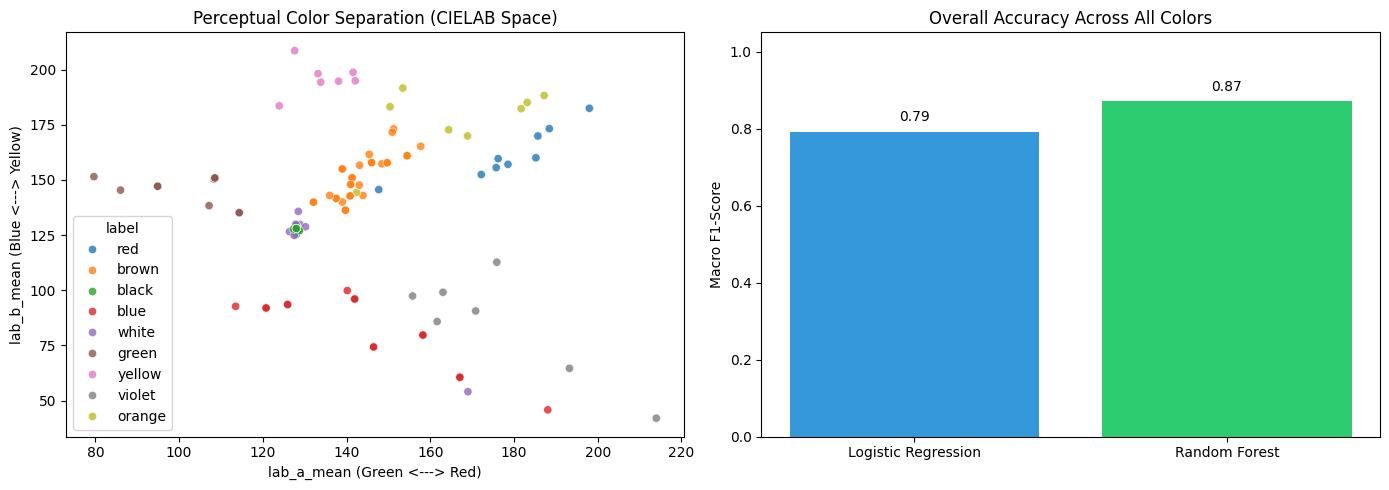

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ---------------------------------------------------------
# 1. High-Precision Feature Extraction
# ---------------------------------------------------------
def extract_rich_color_features(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    # Simple Background Masking: Exclude near-white/bright background pixels
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = gray < 240  # Keep non-background pixels
    
    if np.sum(mask) == 0:  # Fallback if whole image is filtered
        mask = np.ones_like(gray, dtype=bool)

    # Extract color-defining statistics on non-background pixels
    return {
        # Core Color Identity (Means)
        'hsv_hue_mean': np.mean(img_hsv[:, :, 0][mask]),      # Actual Color (0-180)
        'hsv_sat_mean': np.mean(img_hsv[:, :, 1][mask]),      # Color Purity
        'lab_a_mean':   np.mean(img_lab[:, :, 1][mask]),      # Green (-128) to Red (+127)
        'lab_b_mean':   np.mean(img_lab[:, :, 2][mask]),      # Blue (-128) to Yellow (+127)
        'rgb_r_mean':   np.mean(img_rgb[:, :, 0][mask]),
        'rgb_g_mean':   np.mean(img_rgb[:, :, 1][mask]),
        'rgb_b_mean':   np.mean(img_rgb[:, :, 2][mask]),
        
        # Color Variance (STDs)
        'rgb_b_std':    np.std(img_rgb[:, :, 2][mask]),
        'rgb_g_std':    np.std(img_rgb[:, :, 1][mask]),
    }

print("Extracting rich color features from images...")
features_data = df['filepath'].apply(extract_rich_color_features)
X = pd.DataFrame(list(features_data))
y = df['label'].str.lower()

# Drop missing rows
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Split dataset across ALL color targets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Scale Features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

# ---------------------------------------------------------
# 2. Check Collinearity across New Feature Set
# ---------------------------------------------------------
vif_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "VIF": [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])]
})
print("\n=== Feature Collinearity (VIF Scores) ===")
print(vif_df)

# ---------------------------------------------------------
# 3. Model Comparisons
# ---------------------------------------------------------
# Model A: Logistic Regression (L2 Regularized to handle collinearity)
lr_model = LogisticRegression(multi_class='multinomial', penalty='l2', C=1.0, max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

# Model B: Random Forest (Non-linear decision tree boundary)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n==================================================")
print(" LOGISTIC REGRESSION (COL-CONTROLLED MULTI-LINEAR)")
print("==================================================")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print("\n==================================================")
print(" RANDOM FOREST (TREE MODEL ON RICH COLOR FEATURES)")
print("==================================================")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# ---------------------------------------------------------
# 4. Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Perceptual Color Separation (LAB a* vs b*)
sns.scatterplot(
    data=X_train.assign(label=y_train), 
    x='lab_a_mean', y='lab_b_mean', hue='label', 
    palette='tab10', alpha=0.8, ax=axes[0]
)
axes[0].set_title('Perceptual Color Separation (CIELAB Space)')
axes[0].set_xlabel('lab_a_mean (Green <---> Red)')
axes[0].set_ylabel('lab_b_mean (Blue <---> Yellow)')

# Plot 2: Model Performance Comparison
f1_lr = f1_score(y_test, y_pred_lr, average='macro', zero_division=0)
f1_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

bars = axes[1].bar(['Logistic Regression', 'Random Forest'], [f1_lr, f1_rf], color=['#3498db', '#2ecc71'])
axes[1].set_ylabel('Macro F1-Score')
axes[1].set_ylim(0, 1.05)
axes[1].set_title('Overall Accuracy Across All Colors')

for bar in bars:
    yval = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2.0, yval + 0.02, f'{yval:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Extracting color features from existing DataFrame...

[+] Optimal Cluster Count (K): 17 (Distinct from Class Count: 9)

 LOGISTIC REGRESSION ON OPTIMAL CLUSTER DISTANCES
              precision    recall  f1-score   support

       black       0.86      1.00      0.92         6
        blue       1.00      0.40      0.57         5
       brown       0.77      1.00      0.87        10
       green       1.00      1.00      1.00         4
      orange       1.00      0.50      0.67         2
         red       1.00      0.67      0.80         3
      violet       0.75      0.60      0.67         5
       white       0.67      1.00      0.80         4
      yellow       1.00      1.00      1.00         3

    accuracy                           0.83        42
   macro avg       0.89      0.80      0.81        42
weighted avg       0.86      0.83      0.82        42



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


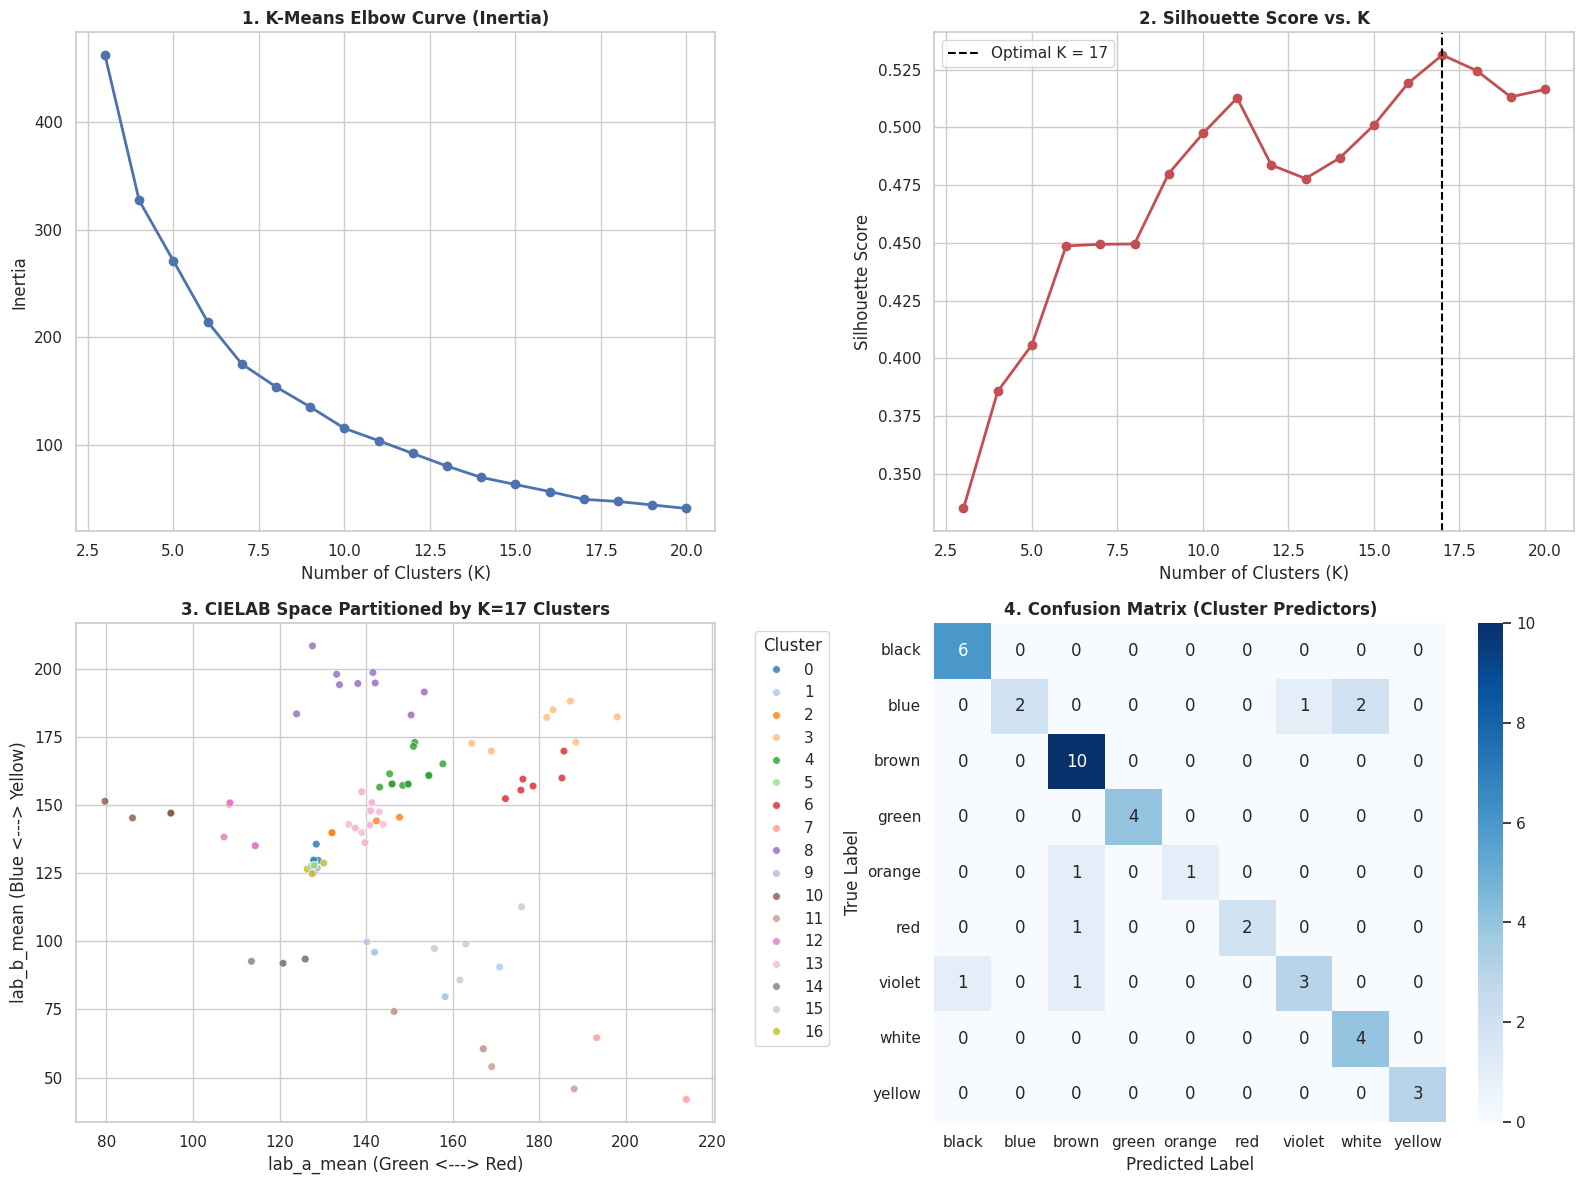

In [12]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Set plot style
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Feature Extraction Function
# ---------------------------------------------------------
def extract_rich_color_features(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    
    # Background Masking: Exclude bright background pixels (near-white)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = gray < 240
    if np.sum(mask) == 0:
        mask = np.ones_like(gray, dtype=bool)

    return {
        'hsv_hue_mean': np.mean(img_hsv[:, :, 0][mask]),
        'hsv_sat_mean': np.mean(img_hsv[:, :, 1][mask]),
        'lab_a_mean':   np.mean(img_lab[:, :, 1][mask]),
        'lab_b_mean':   np.mean(img_lab[:, :, 2][mask]),
        'rgb_r_mean':   np.mean(img_rgb[:, :, 0][mask]),
        'rgb_g_mean':   np.mean(img_rgb[:, :, 1][mask]),
        'rgb_b_mean':   np.mean(img_rgb[:, :, 2][mask]),
    }

# ---------------------------------------------------------
# 2. Extract Features & Train/Test Split
# ---------------------------------------------------------
print("Extracting color features from existing DataFrame...")
features_data = df['filepath'].apply(extract_rich_color_features)
X = pd.DataFrame(list(features_data))
y = df['label'].str.lower()

# Drop unreadable rows
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Standardize raw features prior to clustering
raw_scaler = StandardScaler()
X_train_scaled = raw_scaler.fit_transform(X_train)
X_test_scaled = raw_scaler.transform(X_test)

# ---------------------------------------------------------
# 3. Determine Optimal K (Silhouette Score & Elbow Curve)
# ---------------------------------------------------------
k_range = range(3, 21)  # Search K from 3 to 20
inertias = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_train_scaled, cluster_labels))

# Automatically select K with maximum silhouette score
optimal_k = k_range[np.argmax(silhouette_scores)]
print(f"\n[+] Optimal Cluster Count (K): {optimal_k} (Distinct from Class Count: {y.nunique()})")

# ---------------------------------------------------------
# 4. Fit K-Means & Transform to Scaled Cluster Distances
# ---------------------------------------------------------
kmeans_opt = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_opt.fit(X_train_scaled)

# Compute raw cluster distances
X_train_dists = kmeans_opt.transform(X_train_scaled)
X_test_dists = kmeans_opt.transform(X_test_scaled)

# SCALE CLUSTER DISTANCES (Fixes Convergence Warning)
cluster_scaler = StandardScaler()
X_train_cluster_scaled = cluster_scaler.fit_transform(X_train_dists)
X_test_cluster_scaled = cluster_scaler.transform(X_test_dists)

# ---------------------------------------------------------
# 5. Fit Logistic Regression on Scaled Cluster Distances
# ---------------------------------------------------------
clf = LogisticRegression(
    multi_class='multinomial', 
    solver='saga',      # Efficient solver for scaled multi-class spaces
    max_iter=5000,      # Elevated iteration cap to guarantee convergence
    C=1.0, 
    random_state=42
)
clf.fit(X_train_cluster_scaled, y_train)

y_pred = clf.predict(X_test_cluster_scaled)

print("\n==================================================")
print(" LOGISTIC REGRESSION ON OPTIMAL CLUSTER DISTANCES")
print("==================================================")
print(classification_report(y_test, y_pred, zero_division=0))

# ---------------------------------------------------------
# 6. Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Elbow Method (Inertia)
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=6)
axes[0, 0].set_title('1. K-Means Elbow Curve (Inertia)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Number of Clusters (K)')
axes[0, 0].set_ylabel('Inertia')

# Plot 2: Silhouette Scores & Selected K
axes[0, 1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=6)
axes[0, 1].axvline(optimal_k, color='black', linestyle='--', label=f'Optimal K = {optimal_k}')
axes[0, 1].set_title('2. Silhouette Score vs. K', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Number of Clusters (K)')
axes[0, 1].set_ylabel('Silhouette Score')
axes[0, 1].legend()

# Plot 3: Discovered Clusters in CIELAB Color Space
train_cluster_assignments = kmeans_opt.labels_
sns.scatterplot(
    x=X_train['lab_a_mean'], 
    y=X_train['lab_b_mean'], 
    hue=train_cluster_assignments, 
    palette='tab20', 
    ax=axes[1, 0], 
    alpha=0.8,
    s=30
)
axes[1, 0].set_title(f'3. CIELAB Space Partitioned by K={optimal_k} Clusters', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('lab_a_mean (Green <---> Red)')
axes[1, 0].set_ylabel('lab_b_mean (Blue <---> Yellow)')
axes[1, 0].legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 4: Confusion Matrix Heatmap
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[1, 1])
axes[1, 1].set_title('4. Confusion Matrix (Cluster Predictors)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Predicted Label')
axes[1, 1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

Extracting polar color features...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 EVALUATION AFTER REFINING BROWN SUB-CLUSTERS
              precision    recall  f1-score   support

       black       1.00      0.33      0.50         6
        blue       1.00      0.60      0.75         5
       brown       0.92      1.00      0.96        11
       green       1.00      1.00      1.00         4
      orange       0.67      1.00      0.80         2
         red       1.00      1.00      1.00         3
      violet       0.43      0.60      0.50         5
       white       0.67      1.00      0.80         4
      yellow       1.00      1.00      1.00         2

    accuracy                           0.81        42
   macro avg       0.85      0.84      0.81        42
weighted avg       0.86      0.81      0.80        42



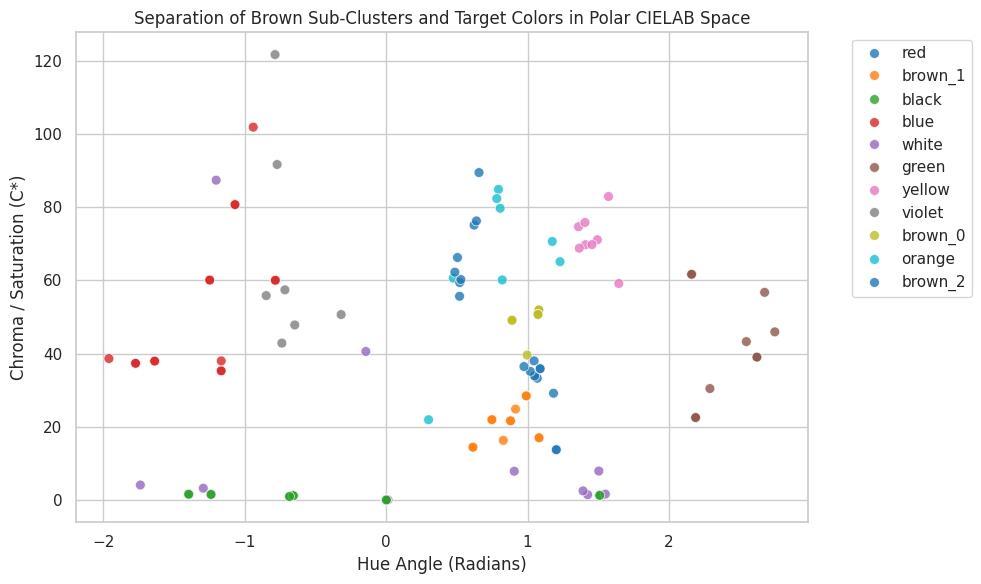

In [13]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------------------------------------
# 1. Feature Extraction: Polar Color Spaces (Chroma & Hue Angle)
# ---------------------------------------------------------
def extract_polar_color_features(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None
        
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    
    # Strict Masking: Filter out dark shadows (<30 L) and high-brightness backgrounds (>230 L)
    L_channel = img_lab[:, :, 0]
    mask = (L_channel > 30) & (L_channel < 230)
    
    if np.sum(mask) == 0:
        mask = np.ones_like(L_channel, dtype=bool)

    # Compute a* and b* from CIELAB
    a = img_lab[:, :, 1][mask] - 128.0
    b = img_lab[:, :, 2][mask] - 128.0
    
    # Chroma C* = sqrt(a^2 + b^2) -> Measures color purity (Brown has low C*, Red/Yellow high C*)
    chroma = np.sqrt(a**2 + b**2)
    
    # Hue Angle h = arctan2(b, a) -> Disambiguates Hue independently of brightness
    hue_angle = np.arctan2(b, a)
    
    return {
        'lab_l_mean': np.mean(img_lab[:, :, 0][mask]),
        'chroma_mean': np.mean(chroma),
        'chroma_std':  np.std(chroma),
        'hue_angle_mean': np.mean(hue_angle),
        'hsv_sat_mean': np.mean(img_hsv[:, :, 1][mask]),
        'hsv_val_mean': np.mean(img_hsv[:, :, 2][mask])
    }

# ---------------------------------------------------------
# 2. Extract Features & Sub-Cluster "Brown"
# ---------------------------------------------------------
print("Extracting polar color features...")
features_data = df['filepath'].apply(extract_polar_color_features)
X = pd.DataFrame(list(features_data))
y = df['label'].str.lower().copy()

# Drop unreadable rows
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Sub-cluster Brown into 3 distinct shades (e.g., Red-Brown, Yellow-Brown, Dark-Brown)
N_BROWN_SUBCLUSTERS = 3
brown_mask = (y == 'brown')

if brown_mask.sum() > 0:
    kmeans_brown = KMeans(n_clusters=N_BROWN_SUBCLUSTERS, random_state=42, n_init=10)
    brown_features_scaled = StandardScaler().fit_transform(X[brown_mask])
    brown_sub_labels = kmeans_brown.fit_predict(brown_features_scaled)
    
    # Update target series with refined sub-labels
    y_refined = y.astype(str).copy()
    y_refined[brown_mask] = [f'brown_{sub}' for sub in brown_sub_labels]
else:
    y_refined = y

# Stratified Split with refined sub-labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y_refined, test_size=0.25, random_state=42, stratify=y_refined
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 3. Model Training with Class Weighting
# ---------------------------------------------------------
# 'class_weight=balanced' penalizes over-predicting dominant classes like Brown
clf = LogisticRegression(
    multi_class='multinomial', 
    solver='saga', 
    max_iter=5000, 
    class_weight='balanced', 
    random_state=42
)
clf.fit(X_train_scaled, y_train)

y_pred_sub = clf.predict(X_test_scaled)

# Remap sub-labels back to original 'brown' for evaluation
y_test_original = y_test.apply(lambda label: 'brown' if 'brown_' in label else label)
y_pred_mapped = pd.Series(y_pred_sub, index=y_test.index).apply(
    lambda label: 'brown' if 'brown_' in label else label
)

print("\n==================================================")
print(" EVALUATION AFTER REFINING BROWN SUB-CLUSTERS")
print("==================================================")
print(classification_report(y_test_original, y_pred_mapped, zero_division=0))

# ---------------------------------------------------------
# 4. Visualization: Chroma vs Hue Angle Space
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=X_train.assign(label=y_train), 
    x='hue_angle_mean', 
    y='chroma_mean', 
    hue='label', 
    palette='tab10', 
    s=50, 
    alpha=0.8
)
plt.title('Separation of Brown Sub-Clusters and Target Colors in Polar CIELAB Space')
plt.xlabel('Hue Angle (Radians)')
plt.ylabel('Chroma / Saturation (C*)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Extracting perceptual features...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 EVALUATION AFTER REFINING GREEN, BLUE, & BROWN SUB-CLUSTERS
              precision    recall  f1-score   support

       black       1.00      0.67      0.80         6
        blue       0.80      0.80      0.80         5
       brown       0.91      1.00      0.95        10
       green       1.00      1.00      1.00         3
      orange       1.00      1.00      1.00         3
         red       1.00      0.67      0.80         3
      violet       0.57      0.80      0.67         5
       white       0.75      0.75      0.75         4
      yellow       1.00      1.00      1.00         3

    accuracy                           0.86        42
   macro avg       0.89      0.85      0.86        42
weighted avg       0.88      0.86      0.86        42



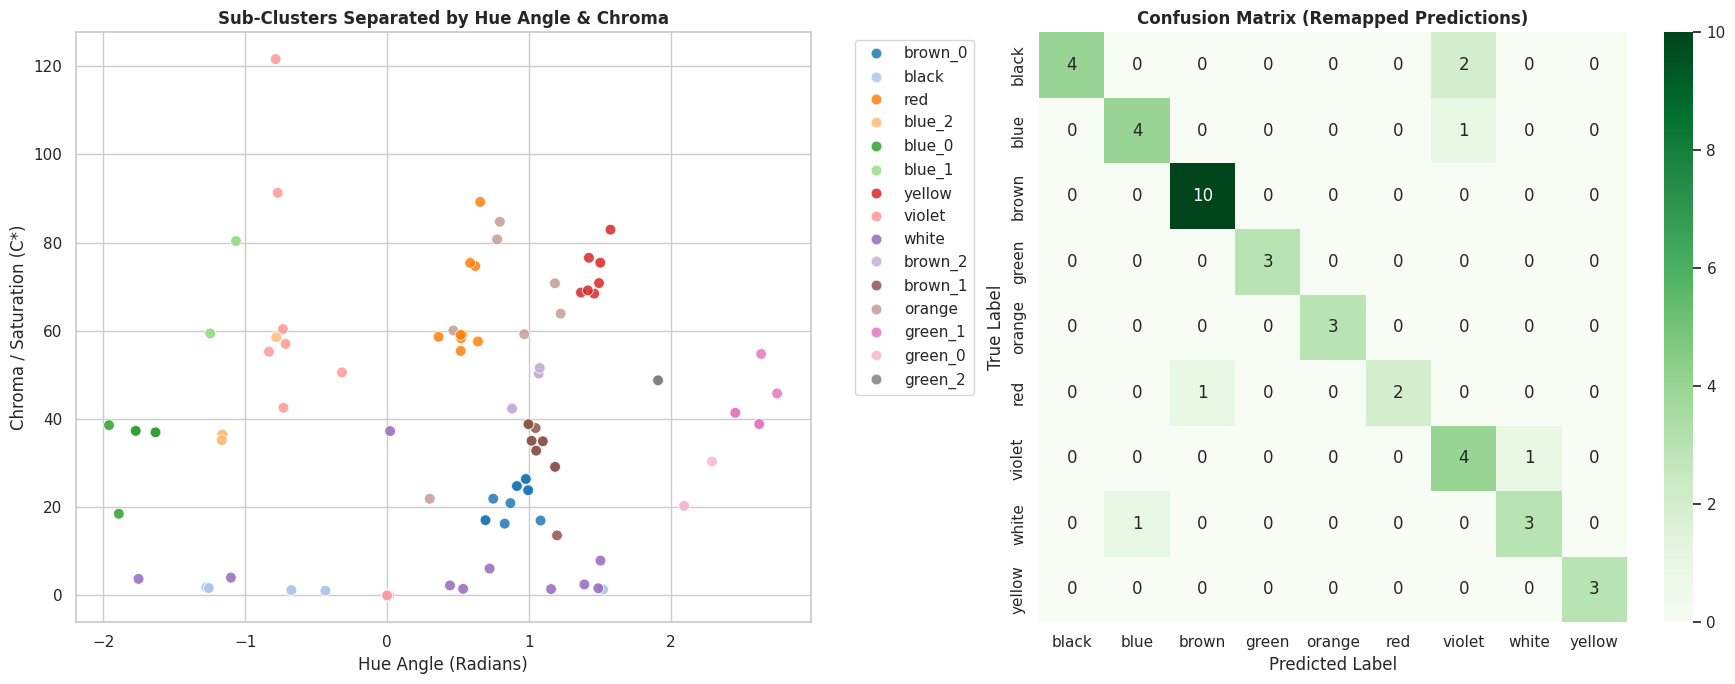

In [14]:
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. Feature Extraction: CIELAB Polar Coordinates + Saturation
# ---------------------------------------------------------
def extract_perceptual_features(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None
        
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    
    # Exclude near-black shadows (<25 L) and near-white backgrounds (>235 L)
    L_channel = img_lab[:, :, 0]
    mask = (L_channel > 25) & (L_channel < 235)
    if np.sum(mask) == 0:
        mask = np.ones_like(L_channel, dtype=bool)

    # Compute a* and b* centered offsets
    a = img_lab[:, :, 1][mask] - 128.0
    b = img_lab[:, :, 2][mask] - 128.0
    
    # Chroma C* (color purity/saturation)
    chroma = np.sqrt(a**2 + b**2)
    
    # Hue Angle h (rads) -> Disambiguates Hue independently of brightness
    hue_angle = np.arctan2(b, a)
    
    return {
        'lab_l_mean':     np.mean(img_lab[:, :, 0][mask]),
        'lab_a_mean':     np.mean(a),
        'lab_b_mean':     np.mean(b),
        'chroma_mean':    np.mean(chroma),
        'hue_angle_mean': np.mean(hue_angle),
        'hsv_sat_mean':   np.mean(img_hsv[:, :, 1][mask]),
        'hsv_val_mean':   np.mean(img_hsv[:, :, 2][mask])
    }

# ---------------------------------------------------------
# 2. Extract Features and Apply Targeted Sub-Clustering
# ---------------------------------------------------------
print("Extracting perceptual features...")
features_data = df['filepath'].apply(extract_perceptual_features)
X = pd.DataFrame(list(features_data))
y = df['label'].str.lower().copy()

# Drop missing rows
valid_idx = X.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# Targets to sub-cluster
target_nuance_classes = ['green', 'blue', 'brown']
N_SUBCLUSTERS = 3  # Create 3 sub-types for each ambiguous class

y_refined = y.astype(str).copy()

for target in target_nuance_classes:
    class_mask = (y == target)
    if class_mask.sum() >= N_SUBCLUSTERS:
        km = KMeans(n_clusters=N_SUBCLUSTERS, random_state=42, n_init=10)
        scaled_sub_feats = StandardScaler().fit_transform(X[class_mask])
        sub_labels = km.fit_predict(scaled_sub_feats)
        y_refined[class_mask] = [f"{target}_{sl}" for sl in sub_labels]

# Train / Test Split on refined sub-labels
X_train, X_test, y_train, y_test = train_test_split(
    X, y_refined, test_size=0.25, random_state=42, stratify=y_refined
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------------------------------------------------------
# 3. Model Training with Balanced Weights
# ---------------------------------------------------------
clf = LogisticRegression(
    multi_class='multinomial', 
    solver='saga', 
    max_iter=5000, 
    class_weight='balanced',  # Penalizes dominant class sink behavior
    random_state=42
)
clf.fit(X_train_scaled, y_train)

y_pred_sub = clf.predict(X_test_scaled)

# Helper function: Remap sub-labels (e.g. 'green_1') back to base classes ('green')
def collapse_sub_labels(label_series):
    return label_series.apply(
        lambda lbl: lbl.split('_')[0] if any(lbl.startswith(t + '_') for t in target_nuance_classes) else lbl
    )

y_test_original = collapse_sub_labels(y_test)
y_pred_mapped = collapse_sub_labels(pd.Series(y_pred_sub, index=y_test.index))

print("\n==================================================")
print(" EVALUATION AFTER REFINING GREEN, BLUE, & BROWN SUB-CLUSTERS")
print("==================================================")
print(classification_report(y_test_original, y_pred_mapped, zero_division=0))

# ---------------------------------------------------------
# 4. Visualizations
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1: Disambiguation in Hue Angle vs. Chroma Space
sns.scatterplot(
    data=X_train.assign(label=y_train), 
    x='hue_angle_mean', 
    y='chroma_mean', 
    hue='label', 
    palette='tab20', 
    s=60, 
    alpha=0.85,
    ax=axes[0]
)
axes[0].set_title('Sub-Clusters Separated by Hue Angle & Chroma', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hue Angle (Radians)')
axes[0].set_ylabel('Chroma / Saturation (C*)')
axes[0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Plot 2: Confusion Matrix across Base Classes
labels = sorted(y_test_original.unique())
cm = confusion_matrix(y_test_original, y_pred_mapped, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Confusion Matrix (Remapped Predictions)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.show()

normalize color

In [15]:
import numpy as np
import pandas as pd
import cv2
from sklearn.preprocessing import StandardScaler

def process_and_normalize_image(image_path):
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        return None
    
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    img_lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    # 1. Background / Luminance Masking (Exclude extreme shadows and white background)
    L_channel = img_lab[:, :, 0]
    mask = (L_channel > 30) & (L_channel < 225)
    if np.sum(mask) == 0:
        mask = np.ones_like(L_channel, dtype=bool)

    # 2. Chromaticity Normalization (r, g, b sum to 1)
    rgb_sum = np.sum(img_rgb, axis=2) + 1e-6  # Add small epsilon to prevent div by 0
    norm_r = img_rgb[:, :, 0] / rgb_sum
    norm_g = img_rgb[:, :, 1] / rgb_sum
    norm_b = img_rgb[:, :, 2] / rgb_sum

    # 3. Extract Chromatic Predictors
    features = {
        'norm_r_mean': np.mean(norm_r[mask]),
        'norm_g_mean': np.mean(norm_g[mask]),
        'norm_b_mean': np.mean(norm_b[mask]),
        'norm_r_std':  np.std(norm_r[mask]),
        'norm_g_std':  np.std(norm_g[mask]),
        'norm_b_std':  np.std(norm_b[mask]),
        
        # HSV & LAB Predictors
        'hue_mean':    np.mean(img_hsv[:, :, 0][mask]),
        'sat_mean':    np.mean(img_hsv[:, :, 1][mask]),
        'lab_a_mean':  np.mean(img_lab[:, :, 1][mask] - 128.0),
        'lab_b_mean':  np.mean(img_lab[:, :, 2][mask] - 128.0),
    }
    return features

# ---------------------------------------------------------
# Build the New Normalized Tabular Dataset
# ---------------------------------------------------------
print("Extracting and normalizing predictor distributions...")
feature_rows = df['filepath'].apply(process_and_normalize_image)

# Convert list of feature dicts into a DataFrame
new_dataset = pd.DataFrame(list(feature_rows))
new_dataset['label'] = df['label'].values
new_dataset['filepath'] = df['filepath'].values

# Clean missing rows
new_dataset = new_dataset.dropna().reset_index(drop=True)

# Separate predictors and target
predictor_cols = [c for c in new_dataset.columns if c not in ['label', 'filepath']]

# 4. Global Distribution Normalization (StandardScaler across all predictors)
scaler = StandardScaler()
new_dataset[predictor_cols] = scaler.fit_transform(new_dataset[predictor_cols])

# Save as a brand new dataset for your midterm project
new_dataset.to_csv("normalized_color_dataset.csv", index=False)

print("\n--- New Dataset Summary ---")
print(new_dataset.head())
print("\nPredictor Distribution Summary (Mean ≈ 0, Std ≈ 1):")
print(new_dataset[predictor_cols].describe().round(2).T[['mean', 'std']])

Extracting and normalizing predictor distributions...

--- New Dataset Summary ---
   norm_r_mean  norm_g_mean  norm_b_mean  norm_r_std  norm_g_std  norm_b_std  \
0     1.064546    -0.201854    -0.949922    1.836297    0.958670    0.936414   
1     0.785467    -0.141610    -0.679279    1.003804   -0.224258    0.965596   
2     0.866258    -0.291047    -0.669796    2.158229    0.177374    1.872122   
3     1.271742    -0.522510    -0.967250    0.292184   -0.180837    0.073588   
4     0.117841     0.070332    -0.076964    2.122968    0.084390    1.847690   

   hue_mean  sat_mean  lab_a_mean  lab_b_mean   label  \
0 -0.798307  0.742964    0.895168    1.112908  Orange   
1 -0.709223  0.438534    1.036434    1.088498  Orange   
2 -0.443270  0.331052    1.231254    1.002526  Orange   
3 -0.852490  0.841467    1.845811    1.440711  Orange   
4 -0.907712 -0.831800    0.091131    0.192964  Orange   

                                            filepath  
0  /kaggle/input/datasets/ayanzadeh93/

RF with normalized colors

Extracting features and filtering out non-color folders...

Cleaned distinct color classes found (9): ['black', 'blue', 'brown', 'green', 'orange', 'red', 'violet', 'white', 'yellow']


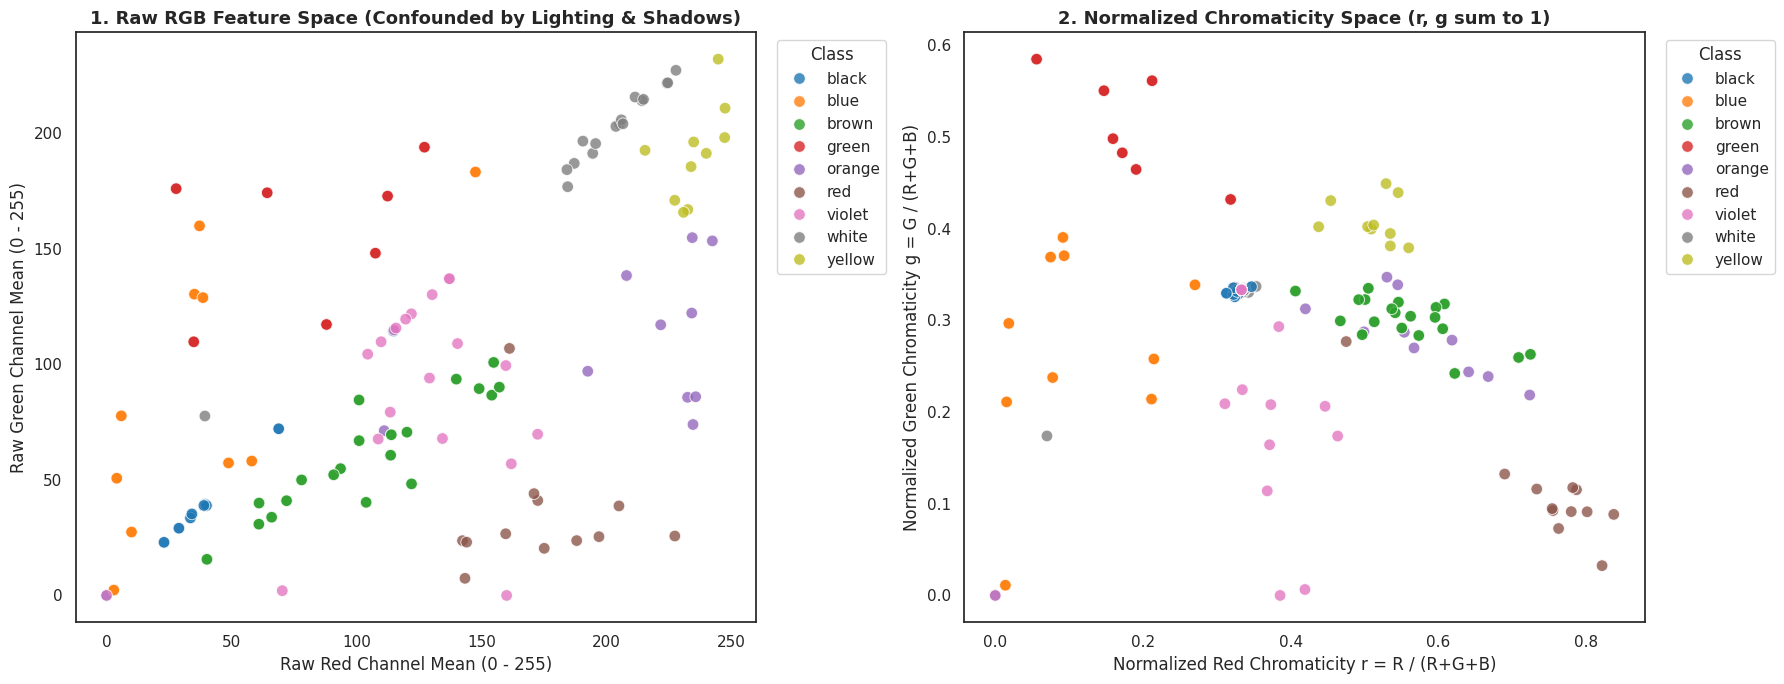

/tmp/ipykernel_58/2767947686.py:148: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='label', y='raw_red', order=active_classes, palette=palette_colors, ax=axes[0])
/tmp/ipykernel_58/2767947686.py:153: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='label', y='norm_red', order=active_classes, palette=palette_colors, ax=axes[1])


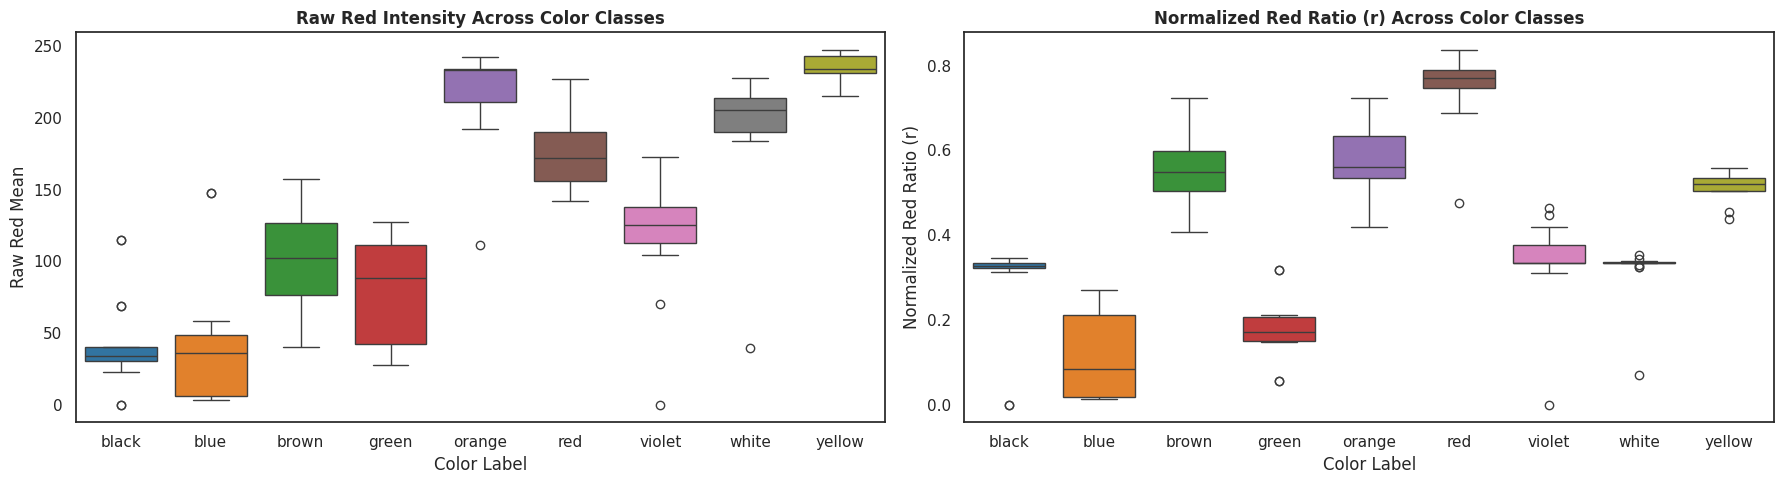

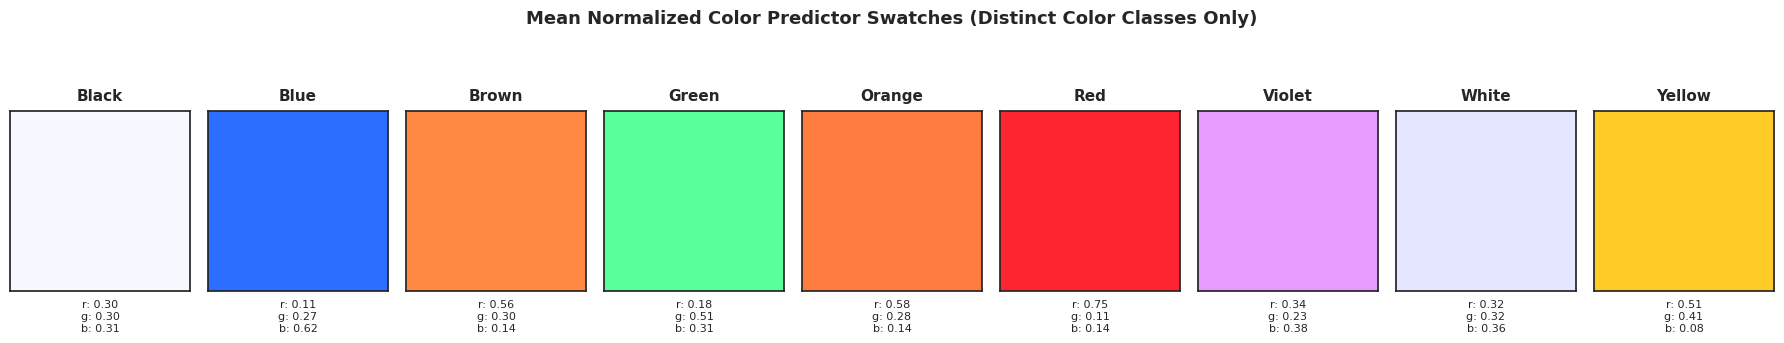

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# ---------------------------------------------------------
# 1. Feature Extraction: Raw vs. Normalized Chromaticity
# ---------------------------------------------------------
def extract_distribution_contrast(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None
        
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    
    # Background mask (ignore extreme highlights/shadows)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray > 20) & (gray < 235)
    if np.sum(mask) == 0:
        mask = np.ones_like(gray, dtype=bool)

    # A. Raw Channel Means
    r_raw = np.mean(img_rgb[:, :, 0][mask])
    g_raw = np.mean(img_rgb[:, :, 1][mask])
    b_raw = np.mean(img_rgb[:, :, 2][mask])

    # B. Chromaticity Normalization (Sum to 1)
    rgb_sum = np.sum(img_rgb, axis=2) + 1e-6
    norm_r_img = img_rgb[:, :, 0] / rgb_sum
    norm_g_img = img_rgb[:, :, 1] / rgb_sum
    norm_b_img = img_rgb[:, :, 2] / rgb_sum

    r_norm = np.mean(norm_r_img[mask])
    g_norm = np.mean(norm_g_img[mask])
    b_norm = np.mean(norm_b_img[mask])

    return {
        'raw_red': r_raw,
        'raw_green': g_raw,
        'raw_blue': b_raw,
        'norm_red': r_norm,
        'norm_green': g_norm,
        'norm_blue': b_norm
    }

# ---------------------------------------------------------
# 2. Strict Label Extraction (Only Color Folders Allowed)
# ---------------------------------------------------------
VALID_10_COLORS = [
    'red', 'green', 'blue', 'yellow', 'orange', 
    'brown', 'violet', 'black', 'white', 'grey'
]

def clean_color_label(path_str, raw_label_str):
    """
    Parses paths and strictly keeps only valid color folder names.
    Omits non-color directories like 'mask_test', 'testimg', etc.
    """
    path_parts = [p.lower() for p in os.path.normpath(str(path_str)).split(os.sep)]
    
    # 1. Search folder hierarchy for an exact match with valid colors
    for color in VALID_10_COLORS:
        if color in path_parts:
            return color
            
    # 2. Check raw_label if path didn't explicitly hit a folder match
    clean_raw = str(raw_label_str).lower().strip()
    if clean_raw in VALID_10_COLORS:
        return clean_raw
        
    return None  # Exclude non-color folder names completely

print("Extracting features and filtering out non-color folders...")

# Apply feature extraction
extracted_data = list(df['filepath'].apply(extract_distribution_contrast))
dist_df = pd.DataFrame(extracted_data)

# Strictly parse color names
dist_df['label'] = [
    clean_color_label(p, l) for p, l in zip(df['filepath'], df['label'])
]

# Drop missing features and any non-color folders (None values)
dist_df = dist_df.dropna(subset=['label', 'raw_red']).reset_index(drop=True)

# Select unique valid colors present in dataset
active_classes = sorted(dist_df['label'].unique())

print(f"\nCleaned distinct color classes found ({len(active_classes)}): {active_classes}")

subset_df = dist_df[dist_df['label'].isin(active_classes)].copy()

# ---------------------------------------------------------
# 3. Visualization: Side-by-Side Distribution Contrast
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Palette matching distinct active colors
palette_colors = sns.color_palette("tab10", len(active_classes))

# Left Plot: Raw RGB Distribution
sns.scatterplot(
    data=subset_df, 
    x='raw_red', 
    y='raw_green', 
    hue='label', 
    hue_order=active_classes,
    palette=palette_colors, 
    s=70, 
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('1. Raw RGB Feature Space (Confounded by Lighting & Shadows)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Raw Red Channel Mean (0 - 255)')
axes[0].set_ylabel('Raw Green Channel Mean (0 - 255)')
axes[0].legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')

# Right Plot: Normalized Chromaticity Distribution
sns.scatterplot(
    data=subset_df, 
    x='norm_red', 
    y='norm_green', 
    hue='label', 
    hue_order=active_classes,
    palette=palette_colors, 
    s=70, 
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('2. Normalized Chromaticity Space (r, g sum to 1)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Normalized Red Chromaticity r = R / (R+G+B)')
axes[1].set_ylabel('Normalized Green Chromaticity g = G / (R+G+B)')
axes[1].legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. Boxplot Contrast for Key Predictors
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.boxplot(data=subset_df, x='label', y='raw_red', order=active_classes, palette=palette_colors, ax=axes[0])
axes[0].set_title('Raw Red Intensity Across Color Classes', fontweight='bold')
axes[0].set_xlabel('Color Label')
axes[0].set_ylabel('Raw Red Mean')

sns.boxplot(data=subset_df, x='label', y='norm_red', order=active_classes, palette=palette_colors, ax=axes[1])
axes[1].set_title('Normalized Red Ratio (r) Across Color Classes', fontweight='bold')
axes[1].set_xlabel('Color Label')
axes[1].set_ylabel('Normalized Red Ratio (r)')

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 5. Render Distinct Predictor Swatches
# ---------------------------------------------------------
class_means = subset_df.groupby('label')[['norm_red', 'norm_green', 'norm_blue']].mean().reindex(active_classes)

fig, axes = plt.subplots(1, len(class_means), figsize=(len(class_means) * 2.0, 3))

if len(class_means) == 1:
    axes = [axes]

for ax, (label, row) in zip(axes, class_means.iterrows()):
    r_norm = row['norm_red']
    g_norm = row['norm_green']
    b_norm = row['norm_blue']
    
    norm_rgb = np.array([r_norm, g_norm, b_norm])
    
    # Scale max channel to 1.0 for vivid swatch rendering
    max_val = max(norm_rgb) if max(norm_rgb) > 0 else 1.0
    display_rgb = np.clip(norm_rgb / max_val, 0.0, 1.0)
    
    swatch = np.array([[display_rgb]])
    
    ax.imshow(swatch)
    ax.set_title(f"{label.capitalize()}", fontsize=11, fontweight='bold', pad=8)
    
    caption = f"r: {r_norm:.2f}\ng: {g_norm:.2f}\nb: {b_norm:.2f}"
    ax.set_xlabel(caption, fontsize=8, labelpad=6)
    
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('Mean Normalized Color Predictor Swatches (Distinct Color Classes Only)', 
             fontsize=13, fontweight='bold', y=1.08)
plt.tight_layout()
plt.show()


In [23]:
import pandas as pd

# ---------------------------------------------------------
# 1. Compute Mean Predictor Coordinates per Color Class
# ---------------------------------------------------------
predictor_coords_df = (
    subset_df.groupby('label')[['norm_red', 'norm_green', 'norm_blue']]
    .mean()
    .reset_index()
)

# Rename columns to 'color', 'r', 'g', 'b' and round for clean output
predictor_coords_df = predictor_coords_df.rename(
    columns={
        'label': 'color',
        'norm_red': 'r',
        'norm_green': 'g',
        'norm_blue': 'b',
    }
)

# Format color names to Capitalized (e.g., 'Red', 'Blue')
predictor_coords_df['color'] = predictor_coords_df['color'].str.capitalize()
predictor_coords_df[['r', 'g', 'b']] = predictor_coords_df[['r', 'g', 'b']].round(4)

# Sort alphabetically by color
predictor_coords_df = predictor_coords_df.sort_values('color').reset_index(drop=True)

# ---------------------------------------------------------
# 2. Export to CSV
# ---------------------------------------------------------
export_path = "/kaggle/working/predictor_color_coordinates.csv"
predictor_coords_df.to_csv(export_path, index=False)

print(f"=== Predictor color coordinates successfully saved to '{export_path}' ===")
print(predictor_coords_df)

=== Predictor color coordinates successfully saved to '/kaggle/working/predictor_color_coordinates.csv' ===
    color       r       g       b
0   Black  0.2986  0.3015  0.3090
1    Blue  0.1082  0.2697  0.6221
2   Brown  0.5575  0.3003  0.1422
3   Green  0.1794  0.5106  0.3100
4  Orange  0.5764  0.2822  0.1414
5     Red  0.7480  0.1102  0.1418
6  Violet  0.3428  0.2300  0.3772
7   White  0.3193  0.3239  0.3567
8  Yellow  0.5120  0.4082  0.0798


Predictors used: ['raw_red', 'raw_green', 'raw_blue', 'norm_red', 'norm_green', 'norm_blue']
Classes: ['Black', 'Blue', 'Brown', 'Green', 'Orange', 'Red', 'Violet', 'White', 'Yellow']
Training samples: 132 | Test samples: 33

=== SUCCESS: Saved 'ninecolor_validity_predictions.csv' ===
  filename ground_truth predicted_label  is_correct  confidence
0       82         Blue            Blue        True       0.807
1      113          Red             Red        True       0.980
2      101        Brown           Brown        True       0.973
3      112        Brown           Brown        True       0.987
4      150        Brown           Brown        True       1.000
5       62        Green           Green        True       0.980
6      149        Brown           Brown        True       1.000
7        0       Orange          Orange        True       0.407
8       85         Blue           White       False       0.573
9       94        Brown           Brown        True       0.973

=========

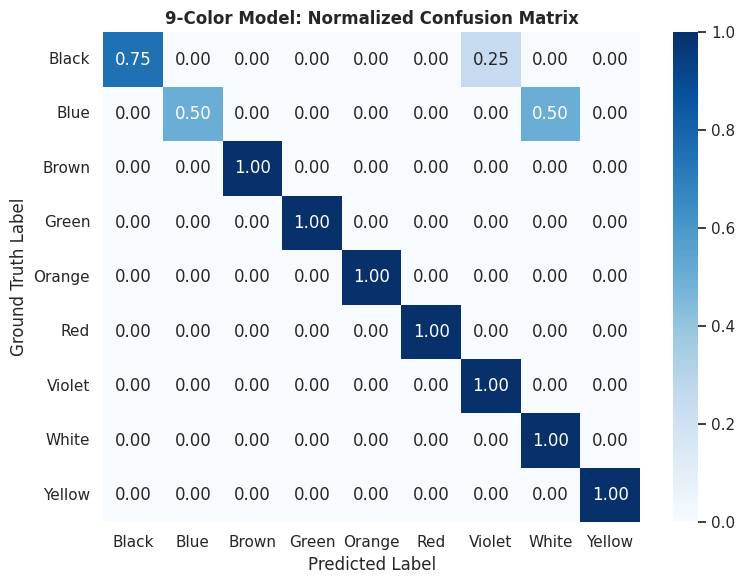

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ---------------------------------------------------------
# 1. Reuse the 9-color dataset already in the notebook
# ---------------------------------------------------------
data = subset_df.copy()                       # <- your existing 9-color frame
data['ground_truth'] = data['label'].str.capitalize()

# Auto-detect predictor columns (drop labels / paths / non-numeric)
drop_cols = {'label', 'ground_truth', 'filepath'}
feature_cols = [c for c in data.columns
                if c not in drop_cols and pd.api.types.is_numeric_dtype(data[c])]
data = data.dropna(subset=feature_cols + ['ground_truth']).reset_index(drop=True)

X = data[feature_cols]
y = data['ground_truth']
paths = data['filepath'] if 'filepath' in data.columns else pd.Series(data.index.astype(str))
print(f"Predictors used: {feature_cols}")
print(f"Classes: {sorted(y.unique())}")

# ---------------------------------------------------------
# 2. Train / Test Split (80% Train / 20% Test)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, paths, test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

# ---------------------------------------------------------
# 3. Train Model & Predict on Labeled Test Data
# ---------------------------------------------------------
rf_model = RandomForestClassifier(n_estimators=150, max_depth=12,
                                  class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_test_pred = rf_model.predict(X_test)
y_test_prob = rf_model.predict_proba(X_test).max(axis=1)

# ---------------------------------------------------------
# 4. Labeled Test Results -> CSV
# ---------------------------------------------------------
test_results_df = pd.DataFrame({
    'filepath': paths_test.values,
    'filename': [os.path.basename(str(p)) for p in paths_test.values],
    'ground_truth': y_test.values,
    'predicted_label': y_test_pred,
    'is_correct': (y_test.values == y_test_pred),
    'confidence': np.round(y_test_prob, 3)
})
test_results_df.to_csv("/kaggle/working/ninecolor_validity_predictions.csv", index=False)
print("\n=== SUCCESS: Saved 'ninecolor_validity_predictions.csv' ===")
print(test_results_df[['filename','ground_truth','predicted_label','is_correct','confidence']].head(10))

# ---------------------------------------------------------
# 5. Evaluation Report + Confusion Matrix
# ---------------------------------------------------------
print("\n================ 9-COLOR VALIDITY TEST REPORT ================")
print(f"Overall Accuracy: {accuracy_score(y_test, y_test_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_test_pred))

plt.figure(figsize=(8, 6))
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=classes, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title("9-Color Model: Normalized Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label"); plt.ylabel("Ground Truth Label")
plt.tight_layout()
plt.show()

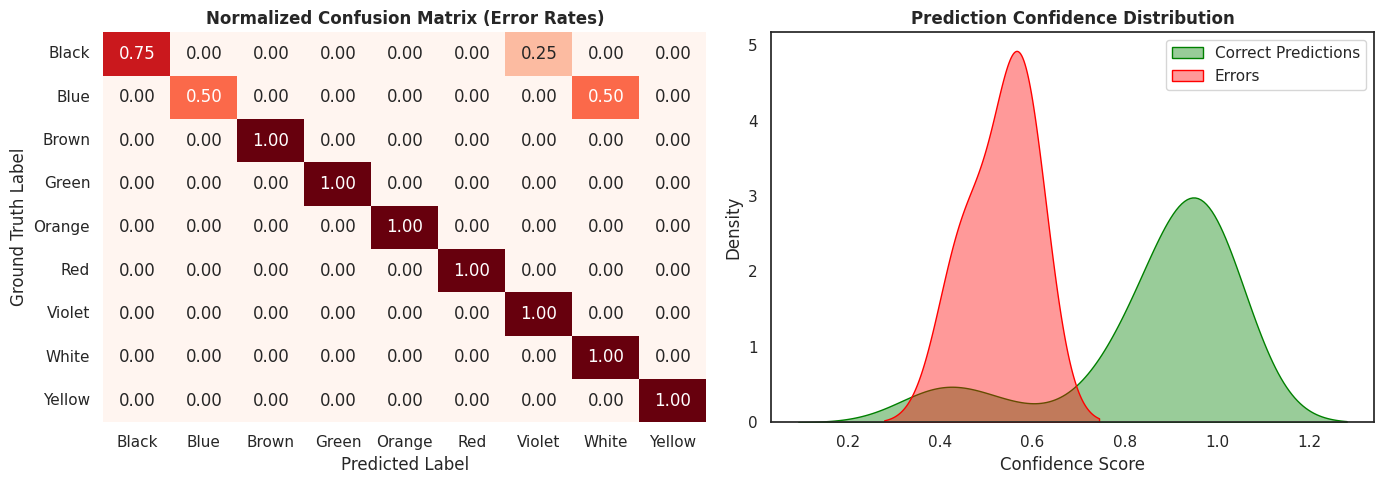

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Load the 9-Color Validity Test CSV (With Ground-Truth Labels)
# ---------------------------------------------------------
csv_path = "/kaggle/working/ninecolor_validity_predictions.csv"
preds_df = pd.read_csv(csv_path)

# Auto-detect column names (including 'ground_truth')
true_col = next(
    (col for col in ['ground_truth', 'true_label', 'label', 'y_true'] if col in preds_df.columns),
    None
)
pred_col = next(
    (col for col in ['predicted_label', 'prediction', 'y_pred'] if col in preds_df.columns),
    None
)

if true_col and pred_col:
    # Use all unique classes present in true or predicted columns
    classes = sorted(list(set(preds_df[true_col].unique()) | set(preds_df[pred_col].unique())))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------------------------------------------------------
    # 2. Normalized Confusion Matrix
    # ---------------------------------------------------------
    cm = confusion_matrix(preds_df[true_col], preds_df[pred_col], labels=classes, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Reds',
        xticklabels=classes, yticklabels=classes, ax=axes[0], cbar=False
    )
    axes[0].set_title('Normalized Confusion Matrix (Error Rates)', fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('Ground Truth Label')

    # ---------------------------------------------------------
    # 3. Confidence Distribution (or Accuracy Fallback)
    # ---------------------------------------------------------
    conf_col = [c for c in preds_df.columns if 'conf' in c.lower() or 'prob' in c.lower()]

    if conf_col:
        is_correct = (preds_df[true_col] == preds_df[pred_col])

        # Plot correct predictions
        sns.kdeplot(
            preds_df.loc[is_correct, conf_col[0]],
            label='Correct Predictions', color='green', fill=True, alpha=0.4, ax=axes[1]
        )
        # Plot errors if present
        if (~is_correct).sum() > 1:
            sns.kdeplot(
                preds_df.loc[~is_correct, conf_col[0]],
                label='Errors', color='red', fill=True, alpha=0.4, ax=axes[1]
            )

        axes[1].set_title('Prediction Confidence Distribution', fontweight='bold')
        axes[1].set_xlabel('Confidence Score')
        axes[1].legend()
    else:
        # Fallback: Accuracy per Class Bar Plot
        acc_per_class = (
            preds_df.groupby(true_col)
            .apply(lambda g: (g[true_col] == g[pred_col]).mean())
            .reset_index(name='accuracy')
        )
        sns.barplot(data=acc_per_class, x='accuracy', y=true_col, palette='viridis', ax=axes[1])
        axes[1].set_title('Accuracy per Class', fontweight='bold')
        axes[1].set_xlabel('Accuracy (0.0 - 1.0)')
        axes[1].set_ylabel('Ground Truth Label')

    plt.tight_layout()
    plt.show()

else:
    print(f"Loaded CSV columns: {list(preds_df.columns)}")
    print("Error: Could not find ground-truth or prediction column names in the CSV.")

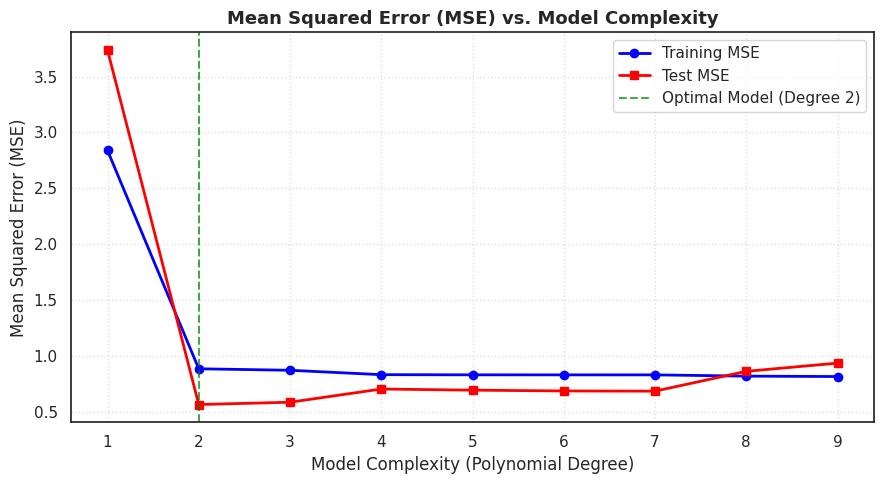

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate synthetic non-linear data with noise
np.random.seed(42)
X = np.random.uniform(-3, 3, size=(100, 1))
y = 0.5 * X.squeeze()**2 + X.squeeze() + 2 + np.random.normal(0, 1, size=100)

# Split into Training and Testing Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

degrees = range(1, 10)
train_mses = []
test_mses = []

# Compute MSE for varying model complexities (polynomial degrees)
for degree in degrees:
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    # Compute Predictions and MSEs
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)
    
    train_mses.append(mean_squared_error(y_train, y_train_pred))
    test_mses.append(mean_squared_error(y_test, y_test_pred))

# Plot Training vs Test MSE
plt.figure(figsize=(9, 5))
plt.plot(degrees, train_mses, label='Training MSE', color='blue', marker='o', linewidth=2)
plt.plot(degrees, test_mses, label='Test MSE', color='red', marker='s', linewidth=2)

# Highlight minimum Test MSE point
best_deg = degrees[np.argmin(test_mses)]
plt.axvline(best_deg, linestyle='--', color='green', alpha=0.7, label=f'Optimal Model (Degree {best_deg})')

plt.title('Mean Squared Error (MSE) vs. Model Complexity', fontsize=13, fontweight='bold')
plt.xlabel('Model Complexity (Polynomial Degree)')
plt.ylabel('Mean Squared Error (MSE)')
plt.xticks(degrees)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

<>:19: SyntaxWarning: invalid escape sequence '\h'
<>:19: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_58/305421243.py:19: SyntaxWarning: invalid escape sequence '\h'
  ax.plot(x_line, m*x_line + c, color='blue', linewidth=2, label='Fitted Line ($\hat{f}(x)$)')


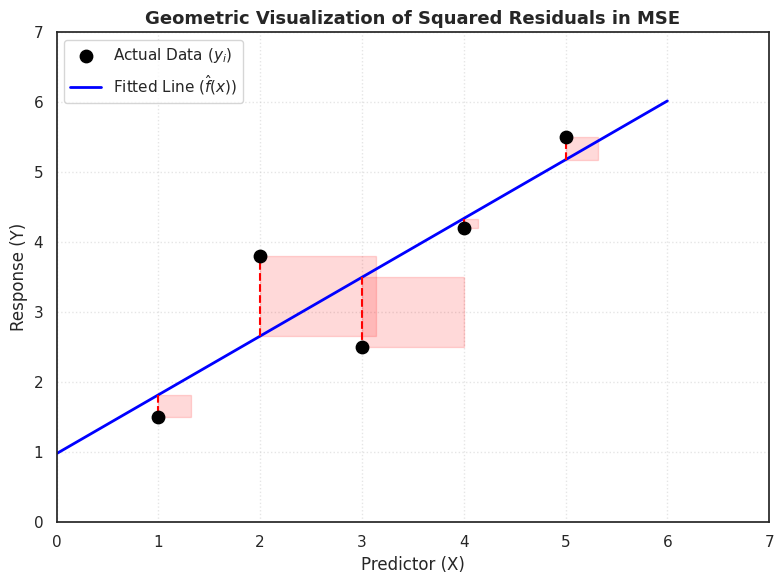

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Data points
np.random.seed(10)
x_pts = np.array([1, 2, 3, 4, 5])
y_pts = np.array([1.5, 3.8, 2.5, 4.2, 5.5])

# Fitted line y = m*x + c
m, c = np.polyfit(x_pts, y_pts, 1)
y_pred = m * x_pts + c

fig, ax = plt.subplots(figsize=(8, 6))

# Plot actual data points & regression line
ax.scatter(x_pts, y_pts, color='black', s=80, zorder=5, label='Actual Data ($y_i$)')
x_line = np.linspace(0, 6, 100)
ax.plot(x_line, m*x_line + c, color='blue', linewidth=2, label='Fitted Line ($\hat{f}(x)$)')

# Draw vertical residual lines and square error boxes
for i in range(len(x_pts)):
    x, y, y_p = x_pts[i], y_pts[i], y_pred[i]
    res = y - y_p
    
    # Residual line
    ax.plot([x, x], [y_p, y], color='red', linestyle='--', linewidth=1.5)
    
    # Draw square corresponding to res^2
    square = patches.Rectangle(
        (x, min(y, y_p)), 
        abs(res), 
        abs(res), 
        linewidth=1, 
        edgecolor='red', 
        facecolor='red', 
        alpha=0.15
    )
    ax.add_patch(square)

ax.set_title('Geometric Visualization of Squared Residuals in MSE', fontsize=13, fontweight='bold')
ax.set_xlabel('Predictor (X)')
ax.set_ylabel('Response (Y)')
ax.legend()
ax.set_xlim(0, 7)
ax.set_ylim(0, 7)
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

In [5]:
import numpy as np, pandas as pd, cv2
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# Your palette: x=R, y=G, t=B
anchors = {
    'gold':{'x':250,'y':200,'t':0}, 'orange':{'x':250,'y':110,'t':0},
    'yellow':{'x':255,'y':255,'t':0}, 'green':{'x':0,'y':255,'t':0},
    'blue':{'x':0,'y':0,'t':255}, 'brown':{'x':180,'y':50,'t':0},
    'nude':{'x':250,'y':180,'t':120}, 'white':{'x':255,'y':255,'t':255},
    'purple':{'x':180,'y':50,'t':255}, 'grey':{'x':170,'y':170,'t':170},
    'red':{'x':255,'y':0,'t':0}, 'pink':{'x':250,'y':0,'t':90},
    'black':{'x':0,'y':0,'t':0}
}

# Alias map: fine anchor name -> dataset class label
alias = {'gold':'yellow','nude':'brown','pink':'red','purple':'violet',
         'grey':'white'}  # fold synonyms into your 9 real classes
def to_class(name): return alias.get(name, name)

names = list(anchors)
# Convert anchors (RGB) to CIELAB so distance ~ perceptual, keeps lightness
A_rgb = np.array([[anchors[n]['x'],anchors[n]['y'],anchors[n]['t']] for n in names], np.uint8)
A_lab = cv2.cvtColor(A_rgb.reshape(-1,1,3), cv2.COLOR_RGB2LAB).reshape(-1,3).astype(float)

def mean_lab(path):
    img = cv2.imread(path)
    if img is None: return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    m = (gray>20)&(gray<235)
    if m.sum()==0: m = np.ones_like(gray,bool)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(float)
    return np.array([lab[:,:,c][m].mean() for c in range(3)])

def anchor_features(path):
    v = mean_lab(path)
    if v is None: return None
    d = np.linalg.norm(A_lab - v, axis=1)          # ΔE to each anchor
    onehot = (d == d.min()).astype(float)          # hard indicator
    soft   = np.exp(-d/20); soft /= soft.sum()     # soft indicator (optional)
    return d, onehot, soft, to_class(names[int(d.argmin())])

In [6]:
# Version B: logistic regression ON the indicators
feats = df['filepath'].apply(anchor_features)
X = pd.DataFrame([f[1] for f in feats], columns=names)   # or f[2] for soft
y = df['label'].str.lower()
Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=.25,stratify=y,random_state=42)
clf = LogisticRegression(max_iter=1000).fit(Xtr,ytr)
print(classification_report(yte, clf.predict(Xte)))

              precision    recall  f1-score   support

       black       0.57      0.67      0.62         6
        blue       0.50      0.20      0.29         5
       brown       0.62      0.80      0.70        10
       green       0.27      1.00      0.42         4
      orange       1.00      0.50      0.67         2
         red       0.00      0.00      0.00         3
      violet       1.00      0.20      0.33         5
       white       1.00      0.25      0.40         4
      yellow       1.00      0.67      0.80         3

    accuracy                           0.52        42
   macro avg       0.66      0.48      0.47        42
weighted avg       0.65      0.52      0.49        42



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Extracting anchor-indicator features...
Training samples: 132 | Test samples: 33

=== SUCCESS: Saved to 'indicator_validity_predictions.csv' ===
  filename ground_truth predicted_label  is_correct  confidence
0    7.jpg         Blue            Blue        True       0.592
1    6.jpg          Red             Red        True       0.397
2    7.jpg        Brown             Red       False       0.397
3    2.jpg        Brown           Black       False       0.455
4    9.jpg        Brown             Red       False       0.397
5    4.jpg        Green           Green        True       0.334
6   10.jpg        Brown             Red       False       0.397
7    6.jpg       Orange             Red       False       0.397
8    2.jpg         Blue           Green       False       0.334
9    6.jpg        Brown             Red       False       0.397

========== INDICATOR MODEL VALIDITY REPORT ==========
Overall Accuracy: 45.45%

              precision    recall  f1-score   support

       Black   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


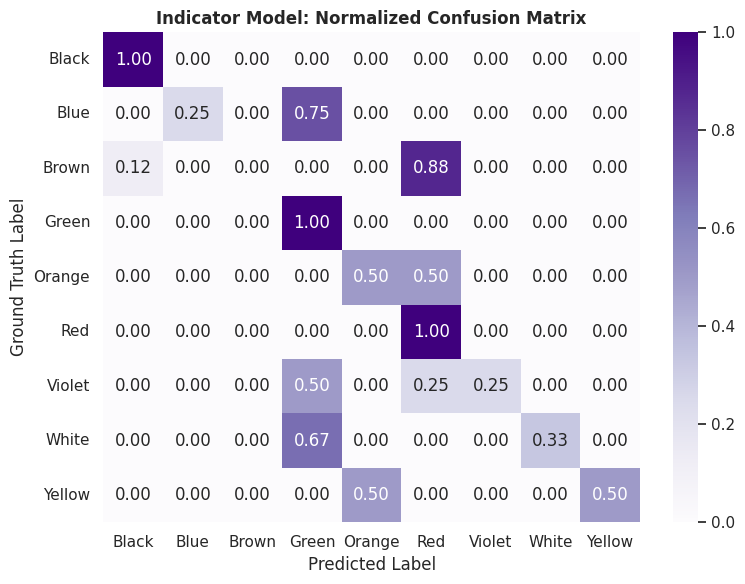

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ---------------------------------------------------------
# 1. La Matrice Anchors (x=R, y=G, t=B)  +  alias -> 9-class map
# ---------------------------------------------------------
anchors = {
    'gold':{'x':250,'y':200,'t':0},   'orange':{'x':250,'y':110,'t':0},
    'yellow':{'x':255,'y':255,'t':0}, 'green':{'x':0,'y':255,'t':0},
    'blue':{'x':0,'y':0,'t':255},     'brown':{'x':180,'y':50,'t':0},
    'nude':{'x':250,'y':180,'t':120}, 'white':{'x':255,'y':255,'t':255},
    'purple':{'x':180,'y':50,'t':255},'grey':{'x':170,'y':170,'t':170},
    'red':{'x':255,'y':0,'t':0},      'pink':{'x':250,'y':0,'t':90},
    'black':{'x':0,'y':0,'t':0}
}
# Fold custom / synonym anchors into the 9 real dataset classes
ALIAS = {'gold':'yellow','nude':'brown','pink':'red','purple':'violet','grey':'white'}
def to_class(name): return ALIAS.get(name, name).capitalize()

VALID_COLORS = ['black','blue','brown','green','orange','red','violet','white','yellow']

anchor_names = list(anchors)
A_rgb = np.array([[anchors[n]['x'],anchors[n]['y'],anchors[n]['t']] for n in anchor_names], np.uint8)
A_lab = cv2.cvtColor(A_rgb.reshape(-1,1,3), cv2.COLOR_RGB2LAB).reshape(-1,3).astype(np.float32)

# ---------------------------------------------------------
# 2. Feature Extraction -> 13 anchor indicators (nearest anchor = 1)
# ---------------------------------------------------------
def extract_indicator_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = (gray > 20) & (gray < 235)
    if mask.sum() == 0:
        mask = np.ones_like(gray, dtype=bool)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    mean_lab = np.array([lab[:,:,c][mask].mean() for c in range(3)])   # perceptual mean color

    dist = np.linalg.norm(A_lab - mean_lab, axis=1)                    # ΔE to each anchor
    onehot = (dist == dist.min()).astype(float)                        # hard indicator variables
    feats = {f'ind_{n}': onehot[i] for i, n in enumerate(anchor_names)}
    feats['_nearest_class'] = to_class(anchor_names[int(dist.argmin())])
    return feats

print("Extracting anchor-indicator features...")
features_list = df['filepath'].apply(extract_indicator_features)
features_df = pd.DataFrame(list(features_list))

# Clean ground-truth labels the same way as your RF model
def clean_color_label(path, raw_label):
    for color in VALID_COLORS:
        if color in str(path).lower():
            return color.capitalize()
    if str(raw_label).lower() in VALID_COLORS:
        return str(raw_label).capitalize()
    return None

features_df['ground_truth'] = [clean_color_label(p, l) for p, l in zip(df['filepath'], df['label'])]
features_df['filepath'] = df['filepath'].values
features_df = features_df.dropna(subset=['ground_truth']).reset_index(drop=True)

indicator_cols = [c for c in features_df.columns if c.startswith('ind_')]
X = features_df[indicator_cols]
y = features_df['ground_truth']

# ---------------------------------------------------------
# 3. Train / Test Split (80/20, stratified)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, features_df['filepath'], test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

# ---------------------------------------------------------
# 4. Indicator Model = multinomial logistic regression on the dummies
# ---------------------------------------------------------
ind_model = LogisticRegression(max_iter=1000, class_weight='balanced')
ind_model.fit(X_train, y_train)
y_test_pred = ind_model.predict(X_test)
y_test_prob = ind_model.predict_proba(X_test).max(axis=1)

# ---------------------------------------------------------
# 5. Labeled Test Results -> CSV
# ---------------------------------------------------------
test_results_df = pd.DataFrame({
    'filepath': paths_test.values,
    'filename': [os.path.basename(p) for p in paths_test.values],
    'ground_truth': y_test.values,
    'predicted_label': y_test_pred,
    'is_correct': (y_test.values == y_test_pred),
    'confidence': np.round(y_test_prob, 3)
})
test_results_df.to_csv("/kaggle/working/indicator_validity_predictions.csv", index=False)
print("\n=== SUCCESS: Saved to 'indicator_validity_predictions.csv' ===")
print(test_results_df[['filename','ground_truth','predicted_label','is_correct','confidence']].head(10))

# ---------------------------------------------------------
# 6. Evaluation Report + Confusion Matrix
# ---------------------------------------------------------
print("\n========== INDICATOR MODEL VALIDITY REPORT ==========")
print(f"Overall Accuracy: {accuracy_score(y_test, y_test_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_test_pred))

plt.figure(figsize=(8, 6))
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=classes, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title("Indicator Model: Normalized Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label"); plt.ylabel("Ground Truth Label")
plt.tight_layout()
plt.show()

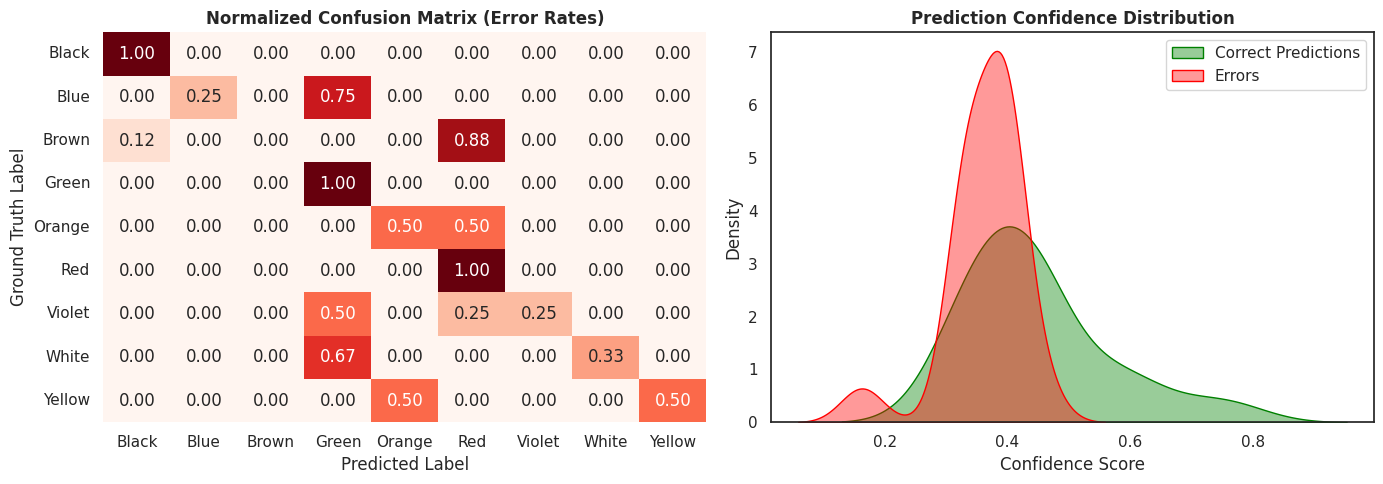

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Load the Indicator Model Validity Test CSV (With Ground-Truth Labels)
# ---------------------------------------------------------
csv_path = "/kaggle/working/indicator_validity_predictions.csv"
preds_df = pd.read_csv(csv_path)

# Auto-detect column names (including 'ground_truth')
true_col = next(
    (col for col in ['ground_truth', 'true_label', 'label', 'y_true'] if col in preds_df.columns),
    None
)
pred_col = next(
    (col for col in ['predicted_label', 'prediction', 'y_pred'] if col in preds_df.columns),
    None
)

if true_col and pred_col:
    # Use all unique classes present in true or predicted columns
    classes = sorted(list(set(preds_df[true_col].unique()) | set(preds_df[pred_col].unique())))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------------------------------------------------------
    # 2. Normalized Confusion Matrix
    # ---------------------------------------------------------
    cm = confusion_matrix(preds_df[true_col], preds_df[pred_col], labels=classes, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Reds',
        xticklabels=classes, yticklabels=classes, ax=axes[0], cbar=False
    )
    axes[0].set_title('Normalized Confusion Matrix (Error Rates)', fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('Ground Truth Label')

    # ---------------------------------------------------------
    # 3. Confidence Distribution (or Accuracy Fallback)
    # ---------------------------------------------------------
    conf_col = [c for c in preds_df.columns if 'conf' in c.lower() or 'prob' in c.lower()]

    if conf_col:
        is_correct = (preds_df[true_col] == preds_df[pred_col])

        # Plot correct predictions
        sns.kdeplot(
            preds_df.loc[is_correct, conf_col[0]],
            label='Correct Predictions', color='green', fill=True, alpha=0.4, ax=axes[1]
        )
        # Plot errors if present
        if (~is_correct).sum() > 1:
            sns.kdeplot(
                preds_df.loc[~is_correct, conf_col[0]],
                label='Errors', color='red', fill=True, alpha=0.4, ax=axes[1]
            )

        axes[1].set_title('Prediction Confidence Distribution', fontweight='bold')
        axes[1].set_xlabel('Confidence Score')
        axes[1].legend()
    else:
        # Fallback: Accuracy per Class Bar Plot
        acc_per_class = (
            preds_df.groupby(true_col)
            .apply(lambda g: (g[true_col] == g[pred_col]).mean())
            .reset_index(name='accuracy')
        )
        sns.barplot(data=acc_per_class, x='accuracy', y=true_col, palette='viridis', ax=axes[1])
        axes[1].set_title('Accuracy per Class', fontweight='bold')
        axes[1].set_xlabel('Accuracy (0.0 - 1.0)')
        axes[1].set_ylabel('Ground Truth Label')

    plt.tight_layout()
    plt.show()

else:
    print(f"Loaded CSV columns: {list(preds_df.columns)}")
    print("Error: Could not find ground-truth or prediction column names in the CSV.")

Extracting features and filtering out non-color folders...

Cleaned distinct color classes found (9): ['black', 'blue', 'brown', 'green', 'orange', 'red', 'violet', 'white', 'yellow']


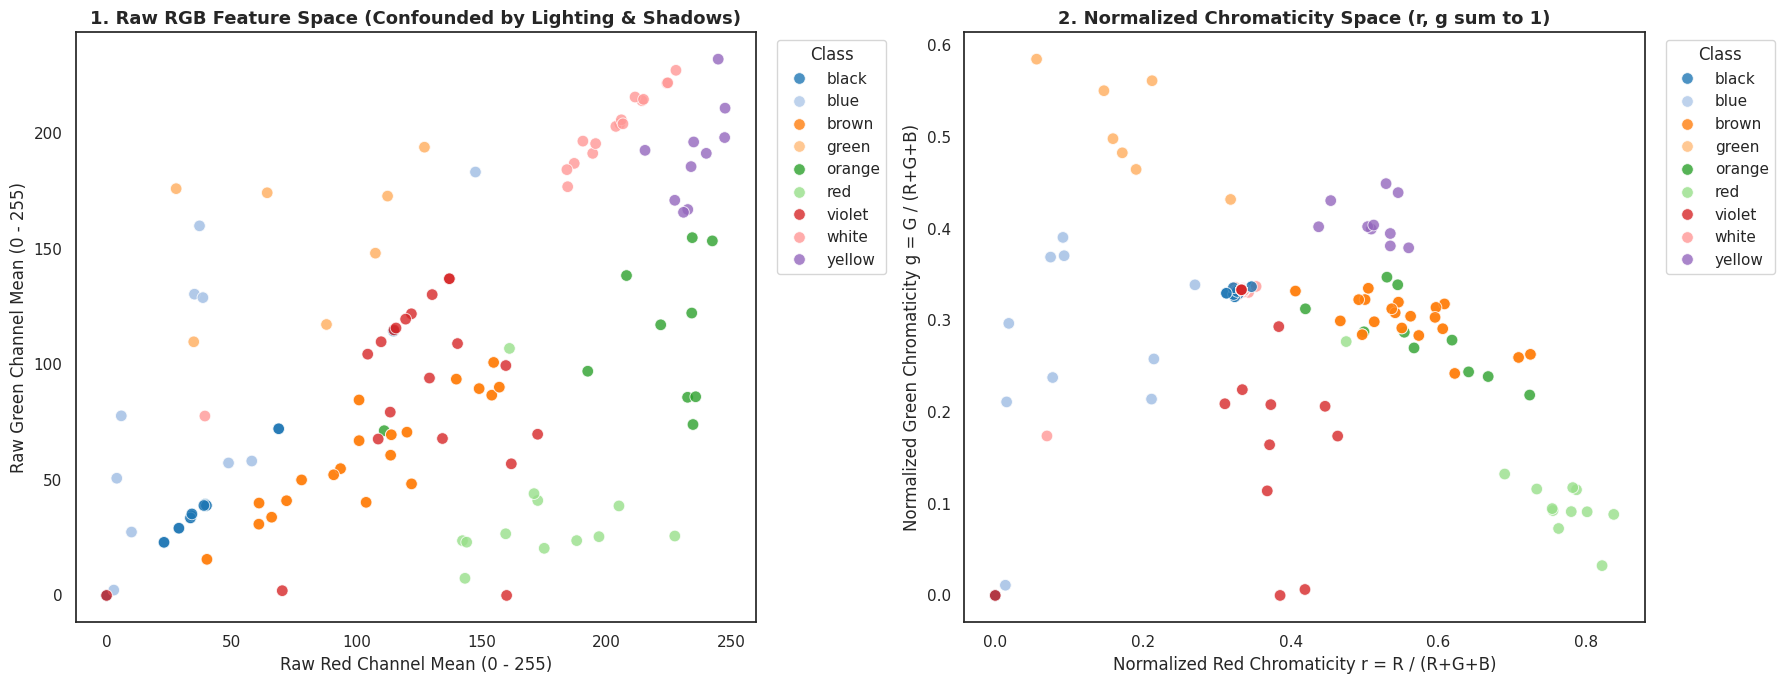

/tmp/ipykernel_58/1741359501.py:128: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='label', y='raw_red', order=active_classes, palette=palette_colors, ax=axes[0])
/tmp/ipykernel_58/1741359501.py:132: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset_df, x='label', y='norm_red', order=active_classes, palette=palette_colors, ax=axes[1])


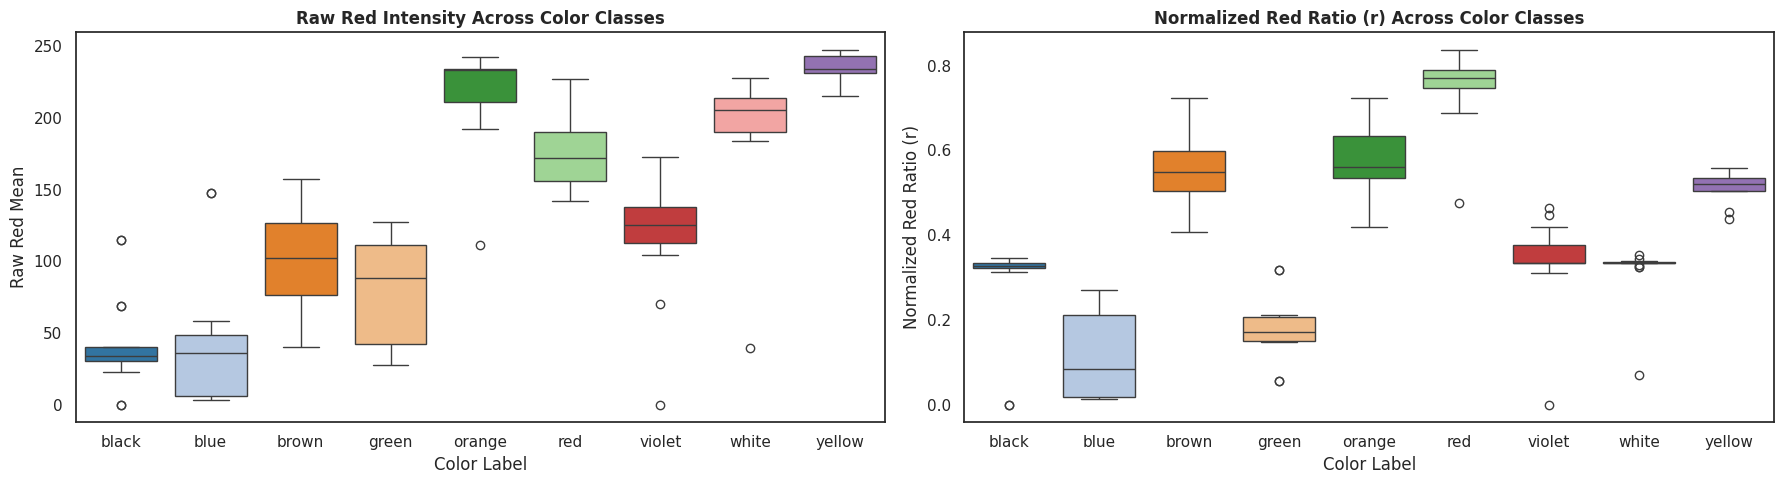

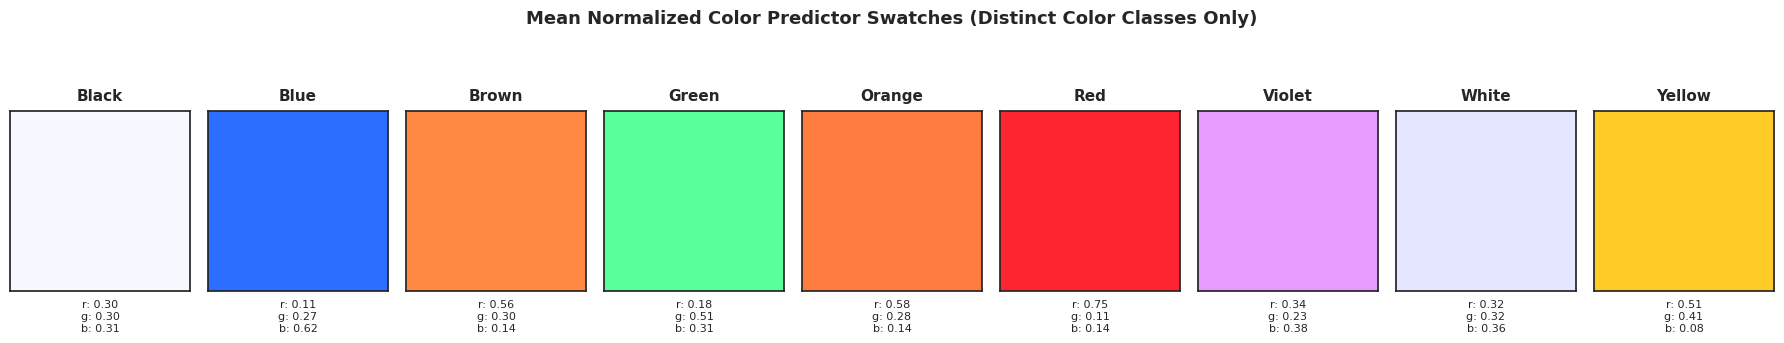

In [2]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="white")

# ---------------------------------------------------------
# 1. Feature Extraction: Raw vs. Normalized Chromaticity
# ---------------------------------------------------------
def extract_distribution_contrast(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        return None

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)

    # Background mask (ignore extreme highlights/shadows)
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    mask = (gray > 20) & (gray < 235)
    if np.sum(mask) == 0:
        mask = np.ones_like(gray, dtype=bool)
    # A. Raw Channel Means
    r_raw = np.mean(img_rgb[:, :, 0][mask])
    g_raw = np.mean(img_rgb[:, :, 1][mask])
    b_raw = np.mean(img_rgb[:, :, 2][mask])
    # B. Chromaticity Normalization (Sum to 1)
    rgb_sum = np.sum(img_rgb, axis=2) + 1e-6
    norm_r_img = img_rgb[:, :, 0] / rgb_sum
    norm_g_img = img_rgb[:, :, 1] / rgb_sum
    norm_b_img = img_rgb[:, :, 2] / rgb_sum
    r_norm = np.mean(norm_r_img[mask])
    g_norm = np.mean(norm_g_img[mask])
    b_norm = np.mean(norm_b_img[mask])
    return {
        'raw_red': r_raw,
        'raw_green': g_raw,
        'raw_blue': b_raw,
        'norm_red': r_norm,
        'norm_green': g_norm,
        'norm_blue': b_norm
    }
# ---------------------------------------------------------
# 2. Strict Label Extraction (Only Color Folders Allowed)
# ---------------------------------------------------------
VALID_16_COLORS = [
    'red', 'green', 'blue', 'yellow', 'orange', 'brown',
    'violet', 'black', 'white', 'grey', 'pink', 'purple',
    'cyan', 'magenta', 'gold', 'tan'
]
def clean_color_label(path_str, raw_label_str):
    """
    Parses paths and strictly keeps only valid color folder names.
    Omits non-color directories like 'mask_test', 'testimg', etc.
    """
    path_parts = [p.lower() for p in os.path.normpath(str(path_str)).split(os.sep)]

    # 1. Search folder hierarchy for an exact match with valid colors
    for color in VALID_16_COLORS:
        if color in path_parts:
            return color

    # 2. Check raw_label if path didn't explicitly hit a folder match
    clean_raw = str(raw_label_str).lower().strip()
    if clean_raw in VALID_16_COLORS:
        return clean_raw

    return None  # Exclude non-color folder names completely
print("Extracting features and filtering out non-color folders...")
# Apply feature extraction
extracted_data = list(df['filepath'].apply(extract_distribution_contrast))
dist_df = pd.DataFrame(extracted_data)
# Strictly parse color names
dist_df['label'] = [
    clean_color_label(p, l) for p, l in zip(df['filepath'], df['label'])
]
# Drop missing features and any non-color folders (None values)
dist_df = dist_df.dropna(subset=['label', 'raw_red']).reset_index(drop=True)
# Select unique valid colors present in dataset
active_classes = sorted(dist_df['label'].unique())
print(f"\nCleaned distinct color classes found ({len(active_classes)}): {active_classes}")
subset_df = dist_df[dist_df['label'].isin(active_classes)].copy()
# ---------------------------------------------------------
# 3. Visualization: Side-by-Side Distribution Contrast
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
# Palette matching distinct active colors
palette_colors = sns.color_palette("tab20", len(active_classes))
# Left Plot: Raw RGB Distribution
sns.scatterplot(
    data=subset_df,
    x='raw_red',
    y='raw_green',
    hue='label',
    hue_order=active_classes,
    palette=palette_colors,
    s=70,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title('1. Raw RGB Feature Space (Confounded by Lighting & Shadows)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Raw Red Channel Mean (0 - 255)')
axes[0].set_ylabel('Raw Green Channel Mean (0 - 255)')
axes[0].legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
# Right Plot: Normalized Chromaticity Distribution
sns.scatterplot(
    data=subset_df,
    x='norm_red',
    y='norm_green',
    hue='label',
    hue_order=active_classes,
    palette=palette_colors,
    s=70,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title('2. Normalized Chromaticity Space (r, g sum to 1)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Normalized Red Chromaticity r = R / (R+G+B)')
axes[1].set_ylabel('Normalized Green Chromaticity g = G / (R+G+B)')
axes[1].legend(title='Class', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()
# ---------------------------------------------------------
# 4. Boxplot Contrast for Key Predictors
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.boxplot(data=subset_df, x='label', y='raw_red', order=active_classes, palette=palette_colors, ax=axes[0])
axes[0].set_title('Raw Red Intensity Across Color Classes', fontweight='bold')
axes[0].set_xlabel('Color Label')
axes[0].set_ylabel('Raw Red Mean')
sns.boxplot(data=subset_df, x='label', y='norm_red', order=active_classes, palette=palette_colors, ax=axes[1])
axes[1].set_title('Normalized Red Ratio (r) Across Color Classes', fontweight='bold')
axes[1].set_xlabel('Color Label')
axes[1].set_ylabel('Normalized Red Ratio (r)')
plt.tight_layout()
plt.show()
# ---------------------------------------------------------
# 5. Render Distinct Predictor Swatches
# ---------------------------------------------------------
class_means = subset_df.groupby('label')[['norm_red', 'norm_green', 'norm_blue']].mean().reindex(active_classes)
fig, axes = plt.subplots(1, len(class_means), figsize=(len(class_means) * 2.0, 3))
if len(class_means) == 1:
    axes = [axes]
for ax, (label, row) in zip(axes, class_means.iterrows()):
    r_norm = row['norm_red']
    g_norm = row['norm_green']
    b_norm = row['norm_blue']

    norm_rgb = np.array([r_norm, g_norm, b_norm])

    # Scale max channel to 1.0 for vivid swatch rendering
    max_val = max(norm_rgb) if max(norm_rgb) > 0 else 1.0
    display_rgb = np.clip(norm_rgb / max_val, 0.0, 1.0)

    swatch = np.array([[display_rgb]])

    ax.imshow(swatch)
    ax.set_title(f"{label.capitalize()}", fontsize=11, fontweight='bold', pad=8)

    caption = f"r: {r_norm:.2f}\ng: {g_norm:.2f}\nb: {b_norm:.2f}"
    ax.set_xlabel(caption, fontsize=8, labelpad=6)

    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Mean Normalized Color Predictor Swatches (Distinct Color Classes Only)', 
             fontsize=13, fontweight='bold', y=1.08)
plt.tight_layout(); plt.show()

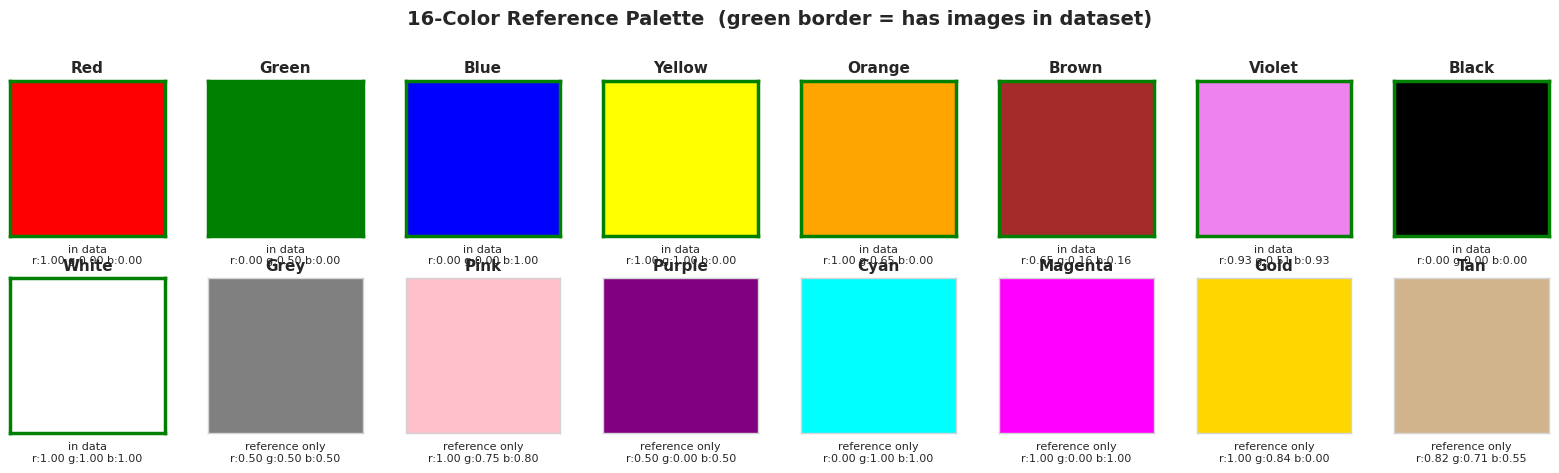

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# ---------------------------------------------------------
# Visualize all 16 target colors as reference swatches
# ---------------------------------------------------------
VALID_16_COLORS = [
    'red', 'green', 'blue', 'yellow', 'orange', 'brown',
    'violet', 'black', 'white', 'grey', 'pink', 'purple',
    'cyan', 'magenta', 'gold', 'tan'
]

# Which of the 16 actually have images in the dataset (from your EDA cell)
try:
    present = set(active_classes)
except NameError:
    present = set()   # run the extraction cell first to flag data-backed colors

fig, axes = plt.subplots(2, 8, figsize=(16, 4.5))
for ax, name in zip(axes.flatten(), VALID_16_COLORS):
    rgb = mcolors.to_rgb(name)             # canonical RGB for the color name
    ax.imshow(np.array([[rgb]]))
    ax.set_title(name.capitalize(), fontsize=11, fontweight='bold', pad=6)

    # Note data availability + the r,g,b coordinates
    tag = "in data" if name in present else "reference only"
    r, g, b = rgb
    ax.set_xlabel(f"{tag}\nr:{r:.2f} g:{g:.2f} b:{b:.2f}", fontsize=8, labelpad=6)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('green' if name in present else 'lightgrey')
        spine.set_linewidth(2.5 if name in present else 1)

plt.suptitle('16-Color Reference Palette  (green border = has images in dataset)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

Extracting anchor-indicator features...
Training samples: 132 | Test samples: 33

=== SUCCESS: Saved to 'indicator16_validity_predictions.csv' ===
  filename ground_truth predicted_label  is_correct  confidence
0    7.jpg         Blue          Violet       False       0.195
1    6.jpg          Red             Red        True       0.413
2    7.jpg        Brown             Red       False       0.413
3    2.jpg        Brown           Black       False       0.513
4    9.jpg        Brown             Red       False       0.413
5    4.jpg        Green           White       False       0.315
6   10.jpg        Brown             Red       False       0.413
7    6.jpg       Orange             Red       False       0.413
8    2.jpg         Blue           White       False       0.315
9    6.jpg        Brown             Red       False       0.413

========== 16-ANCHOR INDICATOR MODEL VALIDITY REPORT ==========
Overall Accuracy: 39.39%

              precision    recall  f1-score   support

   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


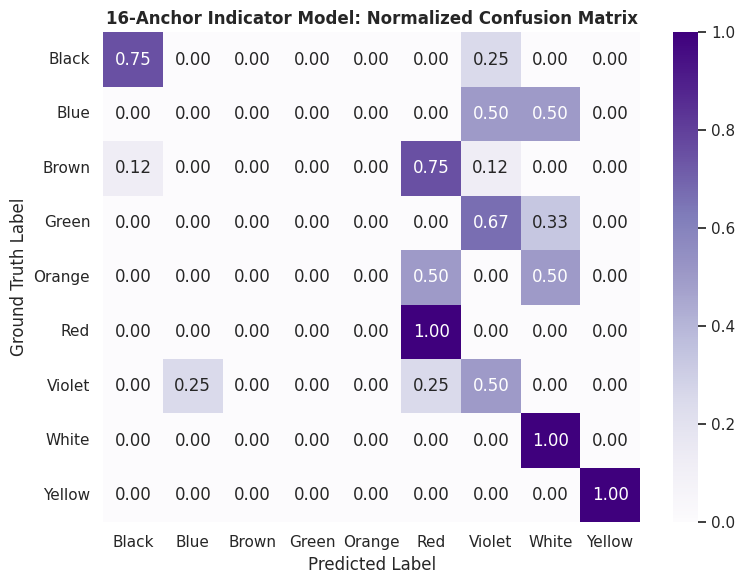

In [4]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# ---------------------------------------------------------
# 1. Standard 16-Color Anchors (canonical RGB, no custom palette)
# ---------------------------------------------------------
ANCHOR_COLORS = [
    'red', 'green', 'blue', 'yellow', 'orange', 'brown',
    'violet', 'black', 'white', 'grey', 'pink', 'purple',
    'cyan', 'magenta', 'gold', 'tan'
]
VALID_COLORS = ['black','blue','brown','green','orange','red','violet','white','yellow']

anchor_names = ANCHOR_COLORS
A_rgb = np.array([[int(c*255) for c in mcolors.to_rgb(n)] for n in anchor_names], np.uint8)
A_lab = cv2.cvtColor(A_rgb.reshape(-1,1,3), cv2.COLOR_RGB2LAB).reshape(-1,3).astype(np.float32)

# ---------------------------------------------------------
# 2. Feature Extraction -> 16 anchor indicators (nearest anchor = 1)
# ---------------------------------------------------------
def extract_indicator_features(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    mask = (gray > 20) & (gray < 235)
    if mask.sum() == 0:
        mask = np.ones_like(gray, dtype=bool)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)
    mean_lab = np.array([lab[:,:,c][mask].mean() for c in range(3)])   # perceptual mean color
    dist = np.linalg.norm(A_lab - mean_lab, axis=1)                    # ΔE to each anchor
    onehot = (dist == dist.min()).astype(float)                        # hard indicator variables
    feats = {f'ind_{n}': onehot[i] for i, n in enumerate(anchor_names)}
    feats['_nearest_anchor'] = anchor_names[int(dist.argmin())]
    return feats

print("Extracting anchor-indicator features...")
features_list = df['filepath'].apply(extract_indicator_features)
features_df = pd.DataFrame(list(features_list))

# Clean ground-truth labels the same way as your RF model
def clean_color_label(path, raw_label):
    for color in VALID_COLORS:
        if color in str(path).lower():
            return color.capitalize()
    if str(raw_label).lower() in VALID_COLORS:
        return str(raw_label).capitalize()
    return None

features_df['ground_truth'] = [clean_color_label(p, l) for p, l in zip(df['filepath'], df['label'])]
features_df['filepath'] = df['filepath'].values
features_df = features_df.dropna(subset=['ground_truth']).reset_index(drop=True)

indicator_cols = [c for c in features_df.columns if c.startswith('ind_')]
X = features_df[indicator_cols]
y = features_df['ground_truth']

# ---------------------------------------------------------
# 3. Train / Test Split (80/20, stratified)
# ---------------------------------------------------------
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, y, features_df['filepath'], test_size=0.20, random_state=42, stratify=y
)
print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")

# ---------------------------------------------------------
# 4. Indicator Model = multinomial logistic regression on the dummies
# ---------------------------------------------------------
ind_model = LogisticRegression(max_iter=1000, class_weight='balanced')
ind_model.fit(X_train, y_train)
y_test_pred = ind_model.predict(X_test)
y_test_prob = ind_model.predict_proba(X_test).max(axis=1)

# ---------------------------------------------------------
# 5. Labeled Test Results -> CSV
# ---------------------------------------------------------
test_results_df = pd.DataFrame({
    'filepath': paths_test.values,
    'filename': [os.path.basename(p) for p in paths_test.values],
    'ground_truth': y_test.values,
    'predicted_label': y_test_pred,
    'is_correct': (y_test.values == y_test_pred),
    'confidence': np.round(y_test_prob, 3)
})
test_results_df.to_csv("/kaggle/working/indicator16_validity_predictions.csv", index=False)
print("\n=== SUCCESS: Saved to 'indicator16_validity_predictions.csv' ===")
print(test_results_df[['filename','ground_truth','predicted_label','is_correct','confidence']].head(10))

# ---------------------------------------------------------
# 6. Evaluation Report + Confusion Matrix
# ---------------------------------------------------------
print("\n========== 16-ANCHOR INDICATOR MODEL VALIDITY REPORT ==========")
print(f"Overall Accuracy: {accuracy_score(y_test, y_test_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_test_pred))

plt.figure(figsize=(8, 6))
classes = sorted(y_test.unique())
cm = confusion_matrix(y_test, y_test_pred, labels=classes, normalize='true')
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Purples', xticklabels=classes, yticklabels=classes)
plt.title("16-Anchor Indicator Model: Normalized Confusion Matrix", fontsize=12, fontweight='bold')
plt.xlabel("Predicted Label"); plt.ylabel("Ground Truth Label")
plt.tight_layout()
plt.show()

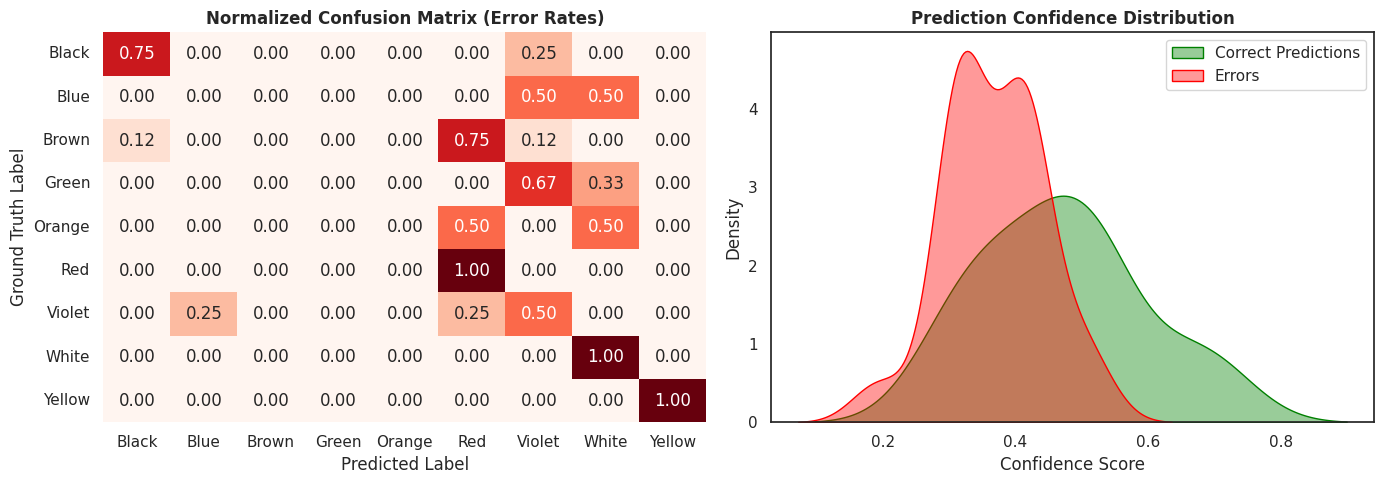

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# ---------------------------------------------------------
# 1. Load the 16-Anchor Indicator Model Validity Test CSV (With Ground-Truth Labels)
# ---------------------------------------------------------
csv_path = "/kaggle/working/indicator16_validity_predictions.csv"
preds_df = pd.read_csv(csv_path)

# Auto-detect column names (including 'ground_truth')
true_col = next(
    (col for col in ['ground_truth', 'true_label', 'label', 'y_true'] if col in preds_df.columns),
    None
)
pred_col = next(
    (col for col in ['predicted_label', 'prediction', 'y_pred'] if col in preds_df.columns),
    None
)

if true_col and pred_col:
    # Use all unique classes present in true or predicted columns
    classes = sorted(list(set(preds_df[true_col].unique()) | set(preds_df[pred_col].unique())))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---------------------------------------------------------
    # 2. Normalized Confusion Matrix
    # ---------------------------------------------------------
    cm = confusion_matrix(preds_df[true_col], preds_df[pred_col], labels=classes, normalize='true')
    sns.heatmap(
        cm, annot=True, fmt='.2f', cmap='Reds',
        xticklabels=classes, yticklabels=classes, ax=axes[0], cbar=False
    )
    axes[0].set_title('Normalized Confusion Matrix (Error Rates)', fontweight='bold')
    axes[0].set_xlabel('Predicted Label')
    axes[0].set_ylabel('Ground Truth Label')

    # ---------------------------------------------------------
    # 3. Confidence Distribution (or Accuracy Fallback)
    # ---------------------------------------------------------
    conf_col = [c for c in preds_df.columns if 'conf' in c.lower() or 'prob' in c.lower()]

    if conf_col:
        is_correct = (preds_df[true_col] == preds_df[pred_col])

        # Plot correct predictions
        sns.kdeplot(
            preds_df.loc[is_correct, conf_col[0]],
            label='Correct Predictions', color='green', fill=True, alpha=0.4, ax=axes[1]
        )
        # Plot errors if present
        if (~is_correct).sum() > 1:
            sns.kdeplot(
                preds_df.loc[~is_correct, conf_col[0]],
                label='Errors', color='red', fill=True, alpha=0.4, ax=axes[1]
            )

        axes[1].set_title('Prediction Confidence Distribution', fontweight='bold')
        axes[1].set_xlabel('Confidence Score')
        axes[1].legend()
    else:
        # Fallback: Accuracy per Class Bar Plot
        acc_per_class = (
            preds_df.groupby(true_col)
            .apply(lambda g: (g[true_col] == g[pred_col]).mean())
            .reset_index(name='accuracy')
        )
        sns.barplot(data=acc_per_class, x='accuracy', y=true_col, palette='viridis', ax=axes[1])
        axes[1].set_title('Accuracy per Class', fontweight='bold')
        axes[1].set_xlabel('Accuracy (0.0 - 1.0)')
        axes[1].set_ylabel('Ground Truth Label')

    plt.tight_layout()
    plt.show()

else:
    print(f"Loaded CSV columns: {list(preds_df.columns)}")
    print("Error: Could not find ground-truth or prediction column names in the CSV.")

Multilinear LogReg (3 top predictors)     F1 = 0.702 ± 0.075
Indicator Model (16 anchors)              F1 = 0.457 ± 0.070
RF2 (normealized predictors)              F1 = 0.947 ± 0.053
Original RF (no normalization)            F1 = 0.936 ± 0.044


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

Sub-cluster Multilinear (Green/Blue/Brown)  F1 = 0.923 ± 0.057


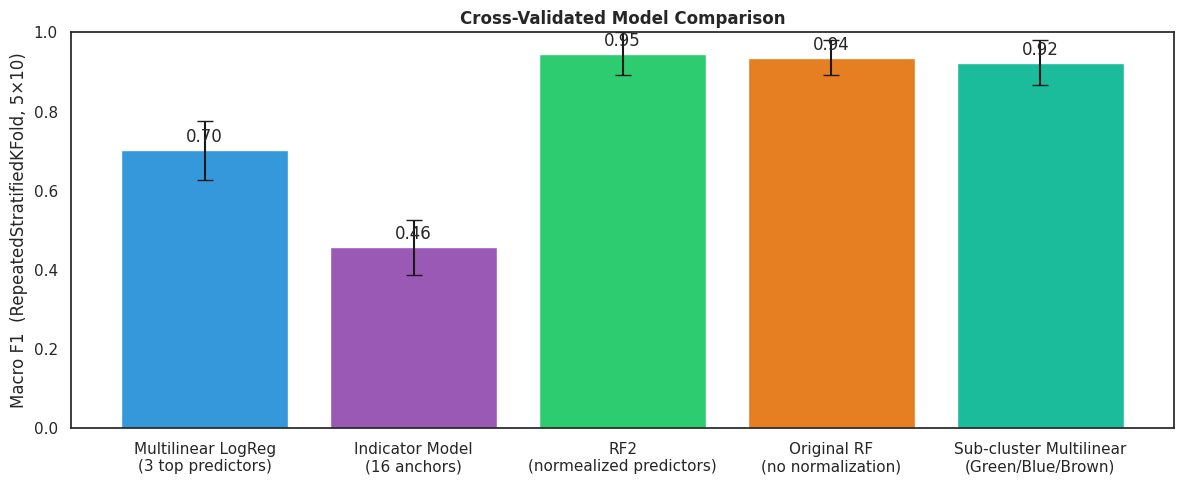

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

# --- Derive perceptual features (cell 19 basis) from existing CIELAB columns ---
if 'chroma_mean' not in feat_df.columns:
    _a = feat_df['lab_a_mean'] - 128.0
    _b = feat_df['lab_b_mean'] - 128.0
    feat_df['chroma_mean']    = np.sqrt(_a**2 + _b**2)
    feat_df['hue_angle_mean'] = np.arctan2(_b, _a)

# Wrapper reproducing cell 19: sub-cluster green/blue/brown, fit balanced
# multinomial logistic, collapse sub-labels back to base classes on predict.
class SubClusterMultilinear(BaseEstimator, ClassifierMixin):
    def __init__(self, targets=('green','blue','brown'), n_sub=3, random_state=42):
        self.targets = targets; self.n_sub = n_sub; self.random_state = random_state
    def fit(self, X, y):
        X = np.asarray(X); y = pd.Series(np.asarray(y)).astype(str).reset_index(drop=True)
        self.scaler_ = StandardScaler().fit(X)
        y_ref = y.copy()
        for t in self.targets:
            m = (y == t).values
            if m.sum() >= self.n_sub:
                sub = KMeans(self.n_sub, random_state=self.random_state, n_init=10) \
                        .fit_predict(StandardScaler().fit_transform(X[m]))
                y_ref[m] = [f"{t}_{s}" for s in sub]
        self.clf_ = LogisticRegression(multi_class='multinomial', solver='saga',
                                       max_iter=5000, class_weight='balanced',
                                       random_state=self.random_state)
        self.clf_.fit(self.scaler_.transform(X), y_ref)
        return self
    def predict(self, X):
        pred = self.clf_.predict(self.scaler_.transform(np.asarray(X)))
        return np.array([p.split('_')[0] if any(p.startswith(t+'_') for t in self.targets) else p
                         for p in pred])

# Feature column sets (all present in feat_df)
log_rf_cols = ['hsv_h_mean','hsv_s_mean','lab_a_mean','lab_b_mean',
               'rgb_r_mean','rgb_g_mean','rgb_b_mean','rgb_b_std','rgb_g_std']
subcluster_cols = ['lab_l_mean','lab_a_mean','lab_b_mean','chroma_mean',
                   'hue_angle_mean','hsv_s_mean','hsv_v_mean']

# ---------------------------------------------------------
# Five models: (name, estimator, feature columns)
# ---------------------------------------------------------
models = {
    'Multilinear LogReg\n(3 top predictors)':
        (make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight='balanced')),
         ['lab_b_mean','lab_a_mean','hue_bin_6']),
    'Indicator Model\n(16 anchors)':
        (LogisticRegression(max_iter=1000, class_weight='balanced'), ind_cols),
    'RF2\n(normealized predictors)':
        (RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
         rich_cols),
    'Original RF\n(no normalization)':
        (RandomForestClassifier(n_estimators=100, random_state=42), log_rf_cols),
    'Sub-cluster Multilinear\n(Green/Blue/Brown)':
        (SubClusterMultilinear(), subcluster_cols),
}

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
results = {}
for name, (est, cols) in models.items():
    scores = cross_val_score(est, feat_df[cols], y, cv=cv, scoring='f1_macro', n_jobs=-1)
    results[name] = (scores.mean(), scores.std())
    print(f"{name.replace(chr(10),' '):40s}  F1 = {scores.mean():.3f} ± {scores.std():.3f}")

# ---------------------------------------------------------
# Comparison bar chart (mean ± std)
# ---------------------------------------------------------
names = list(results)
means = [results[n][0] for n in names]
stds  = [results[n][1] for n in names]
plt.figure(figsize=(12,5))
bars = plt.bar(names, means, yerr=stds, capsize=6,
               color=['#3498db','#9b59b6','#2ecc71','#e67e22','#1abc9c'])
plt.ylabel('Macro F1  (RepeatedStratifiedKFold, 5×10)')
plt.ylim(0, 1.0)
plt.title('Cross-Validated Model Comparison', fontweight='bold')
for b, m in zip(bars, means):
    plt.text(b.get_x()+b.get_width()/2, b.get_height()+0.02, f'{m:.2f}', ha='center')
plt.tight_layout()
plt.show()